# Introduction

In [1]:
!pip install ngaw3_kuehnetal27@git+https://github.com/nikuehn/ngaw3_kuehnetal27

  Cloning https://github.com/nikuehn/ngaw3_kuehnetal27 to /tmp/pip-install-15hsm_ij/ngaw3-kuehnetal27_843d3fae203c426eba2e11dc3adbfd16
  Running command git clone --filter=blob:none --quiet https://github.com/nikuehn/ngaw3_kuehnetal27 /tmp/pip-install-15hsm_ij/ngaw3-kuehnetal27_843d3fae203c426eba2e11dc3adbfd16
  Resolved https://github.com/nikuehn/ngaw3_kuehnetal27 to commit ab205c8d9945850f2fe21ba703d154089dc4dea7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.1 MB/s eta 0:00:00
  Created wheel for ngaw3_kuehnetal27: filename=ngaw3_kuehnetal27-0.1.0-py3-none-any.whl size=7592931 sha256=204e9d3547fee2ebe01313c36f1105ef6a3d03b44f1d1ef93413c992ffc0346a
  Stored in directory: /tmp/pip-ep

In [2]:
import pandas as pd
import numpy as np

import os

import jax
import jax.numpy as jnp

from plotnine import *
from matplotlib import rc

import ngaw3_kuehnetal27
from ngaw3_kuehnetal27.plotting import *

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dir_base = '/content/drive/MyDrive/NGAW3/'
dir_results = os.path.join(dir_base, 'RESULTS', 'spectrum_eas2')
if not os.path.exists(dir_results):
    os.makedirs(dir_results)

dir_plot = os.path.join(dir_results, 'plots')
if not os.path.exists(dir_plot):
    os.makedirs(dir_plot)

## Data

In [9]:
from ngaw3_kuehnetal27.data_loading import load_data, prepare_data
from ngaw3_kuehnetal27.utils import results_data_path

In [10]:
df = pd.read_csv(results_data_path('eas/outlier_ids_dWS_sep.csv'))
outlier_ids = df['motion_id'].to_list()

In [7]:
date_string = '20250919'
flatfile_path = os.path.join(dir_base, 'DATA',f'NGA_West3_EAS_Flatfile_{date_string}.csv')

data_selected, frequencies_used, frequencies_used_names = load_data(flatfile_path,
                                                                    region="WUS",
                                                                    rrup_max=300,
                                                                    outlier_ids=outlier_ids)
data_selected_gl, _, _ = load_data(flatfile_path, region="Global",
                                   frequencies=frequencies_used, rrup_max=300,
                                   outlier_ids=outlier_ids)


data_used, data_eq, data_stat = prepare_data(frequencies_used_names, data_selected, n_rec_eq=1000)
data_used_gl, data_eq_gl, data_stat_gl = prepare_data(frequencies_used_names, data_selected_gl, n_rec_eq=1000)

/usr/local/lib/python3.12/dist-packages/ngaw3_kuehnetal27/data_loading.py:99: DtypeWarning: Columns (6,7,15,37,68,70,71,83,91,92,93,94,95,96,118,137,138) have mixed types. Specify dtype option on import or set low_memory=False.
/usr/local/lib/python3.12/dist-packages/ngaw3_kuehnetal27/data_loading.py:99: DtypeWarning: Columns (6,7,15,37,68,70,71,83,91,92,93,94,95,96,118,137,138) have mixed types. Specify dtype option on import or set low_memory=False.


## Model inputs

In [8]:
from ngaw3_kuehnetal27.model_inputs import extract_model_arrays, build_global_dict, setup_nl_model, build_frequency_cholesky
from ngaw3_kuehnetal27.coefficient_sharing import DEFAULT_COEFFICIENT_SHARING

DEFAULT_COEFFICIENT_SHARING

{'c_0': 'dataset_local',
 'c_m1': 'dataset_local',
 'c_m2': 'shared',
 'c_m3': 'shared',
 'c_hw': 'shared',
 'c_nft_1': 'shared',
 'c_nft_2': 'shared',
 'c_nm': 'shared',
 'c_rev': 'shared',
 'c_gs1': 'dataset_local',
 'c_zt': 'dataset_local',
 'c_vs': 'dataset_local',
 'c_attn': 'dataset_local'}

In [11]:
X_rec, X_eq, X_stat, X_id, Y = extract_model_arrays(data_used, data_eq, data_stat, frequencies_used_names)
global_dict = build_global_dict(data_used_gl, data_eq_gl, data_stat_gl, frequencies_used_names)

In [12]:
frequencies_used_array = jnp.array(frequencies_used)
nl_model_dict = setup_nl_model("hashash_new", frequencies_used_array)
L_freq = build_frequency_cholesky(frequencies_used)

In [ ]:
coeffs_shared = dict(DEFAULT_COEFFICIENT_SHARING)   # fixed: was mutating the shared default
coeffs_shared['c_nm'] = 'dataset_local'
coeffs_shared['c_rev'] = 'dataset_local'

In [ ]:
data_dict = {
    "F": frequencies_used_array,
    "X_rec": X_rec, "X_eq": X_eq, "X_stat": X_stat, "X_id": X_id, "Y": Y,
    "nl_model_dict": nl_model_dict, "L_freq": L_freq, "global_dict": global_dict,
    "attn_eq": True, "attn_Q": True, "regularize_grad": True,
    "calc_nft": "coeff", "ref_basin_id": 1,
    "estimate_gs_break": True, "estimate_zt_break": True,
    "c0_parametric": True, "cgs1_parametric": True,
    "freq_id_grad": np.arange(len(frequencies_used)),
    "dist_cell": None, "save_f_nl": False,
    "func_gs_scaling": "stafford", "estimate_gs_exp": "fixed",
    "calc_dWS": False, "calc_log_lik": False,
    "sharing_config": coeffs_shared,
    "regularization_sigma": 0.05, "spline_df": 7, "spline_degree": 3,
    "include_mag_unc": None,
}

# Results

In [13]:
import json

In [14]:
filestem = 'run1'
filename = results_data_path(f'eas/results_{filestem}.json')
with open(filename, 'r') as f:
    svi_params = json.load(f)

svi_params = {k: jnp.array(v) for k, v in svi_params.items()}
frequencies = svi_params['frequency']

## Coefficients

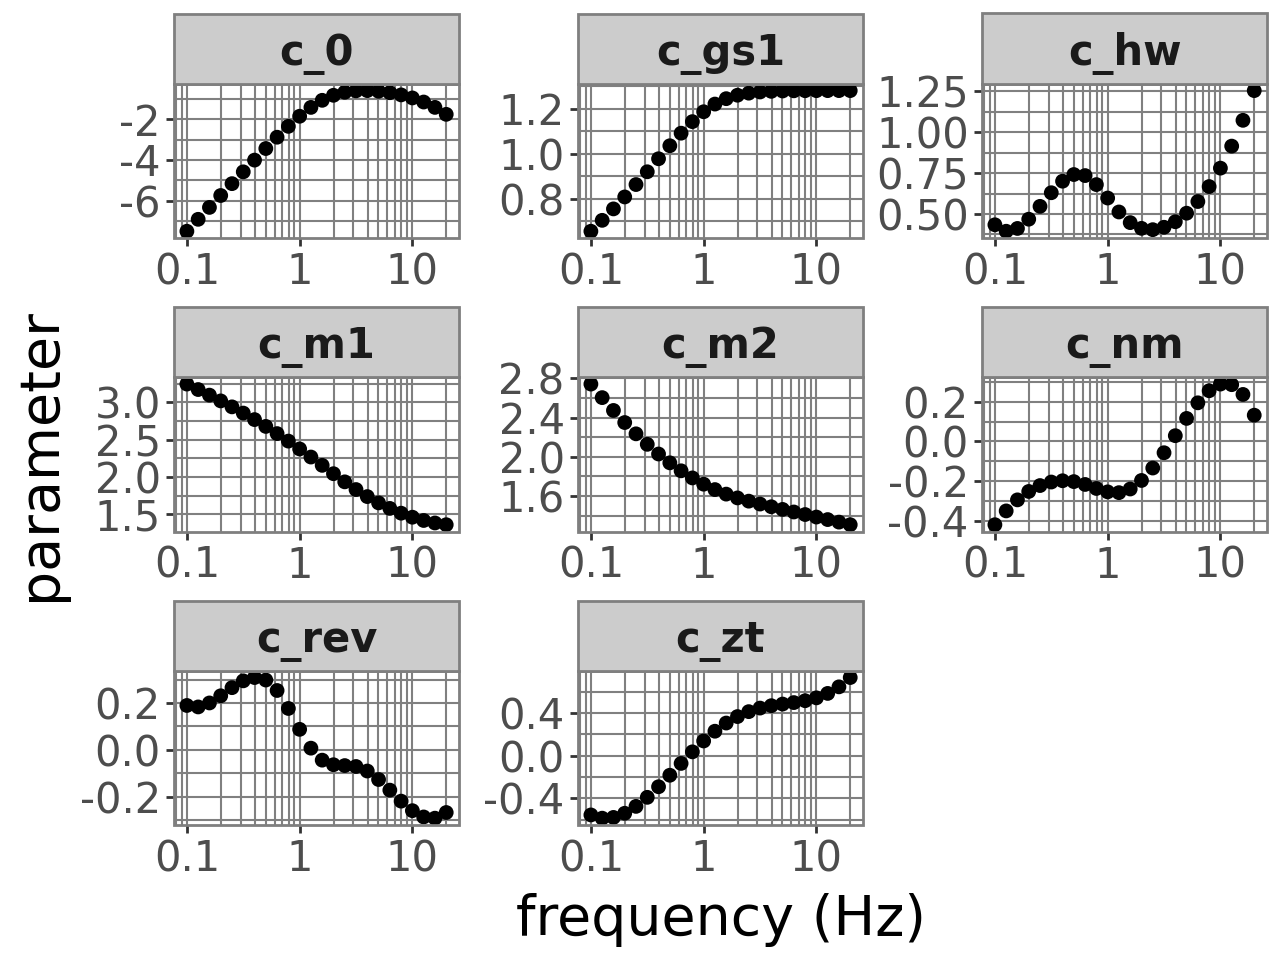

In [15]:
def plot_parameter_against_frequency_facet_svi(deterministics,
                                               plot_vars = ['c_0', 'c_gs1', 'c_nm', 'c_rev',
                                                            'c_hw', 'c_zt', 'c_m1', 'c_m2']):


    dfs = []
    for var in plot_vars:
        df_p = pd.DataFrame({'freq': deterministics['frequency'],
                             'mean': deterministics[var],
                             'var': var})
        dfs.append(df_p)
    df = pd.concat(dfs, ignore_index=True)

    pl = (ggplot(df, aes(x='freq', y='mean')) +
          geom_point(size = 2) +
          facet_wrap('~ var', scales = 'free') +
          scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
          labs(x = 'frequency (Hz)', y = 'parameter') +
          custom_theme)
    return pl
plot_parameter_against_frequency_facet_svi(svi_params)

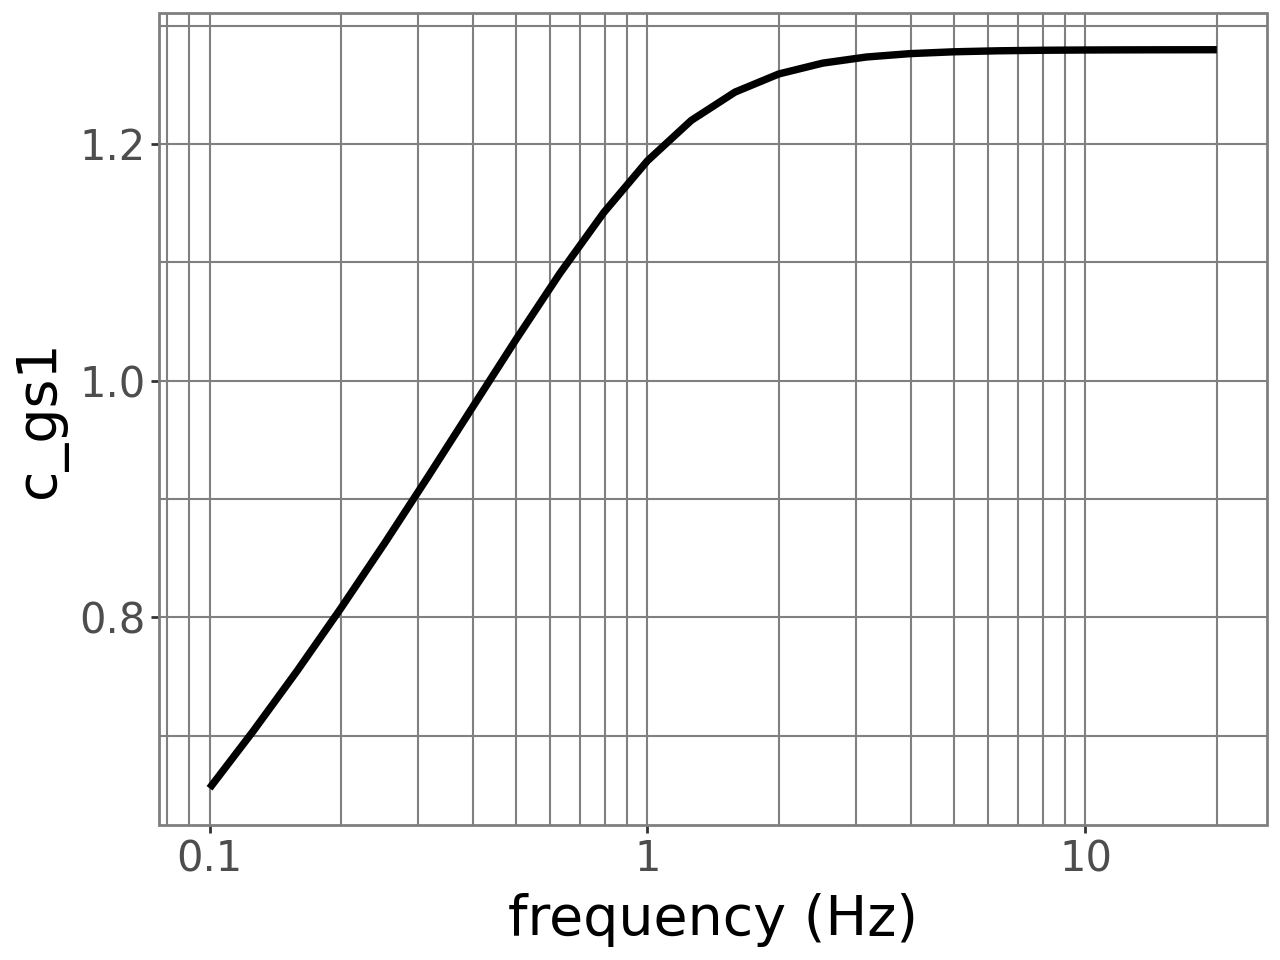

In [ ]:
def plot_parameter_against_frequency(par, deterministics):
    df = pd.DataFrame({'frequency': deterministics['frequency'],
                      'mean': deterministics[par]})

    pl = (ggplot(df, aes(x = 'frequency', y = 'mean')) +
          geom_line(size = 1.5) +
          scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
          labs(y = par, x = 'frequency (Hz)') +
          custom_theme)
    return pl

pl = plot_parameter_against_frequency('c_gs1', svi_params)
pl.show()

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 6.4 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/c_basin.pdf


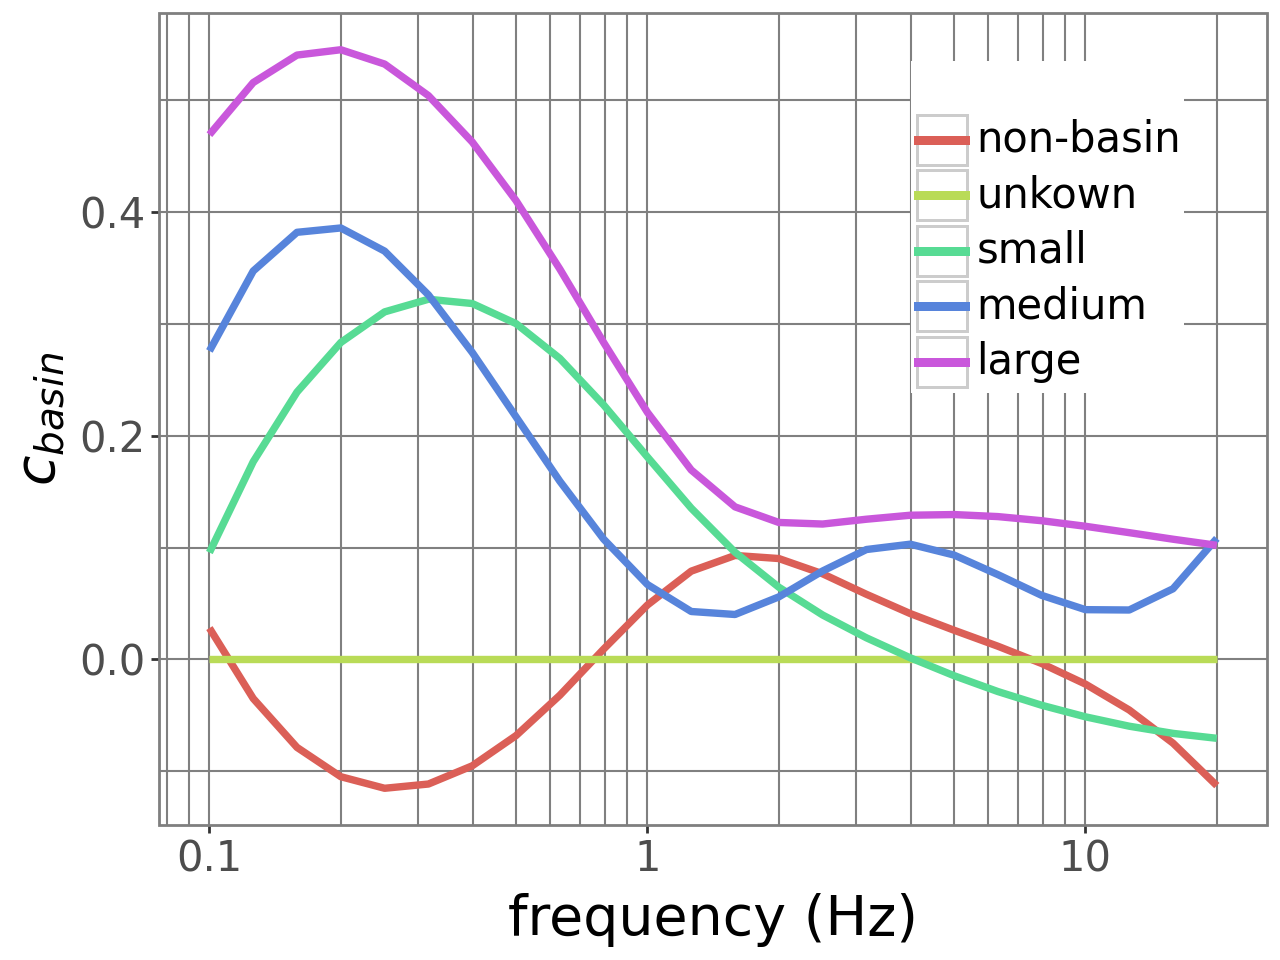

In [ ]:
def plot_basin_against_frequency(svi_params):
    basin_names = ['non-basin', 'unkown', 'small', 'medium', 'large']
    df = pd.DataFrame(svi_params['c_basin'].T, columns=basin_names)
    df['frequency'] = svi_params['frequency']
    df = pd.melt(df, id_vars = 'frequency')
    df['variable'] = pd.Categorical(df['variable'], categories=basin_names)

    pl = (ggplot(df, aes(x = 'frequency', y = 'value', color = 'variable')) +
      geom_line(size = 1.5) +
      scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
      labs(y = r'$c_{basin}$', x = 'frequency (Hz)', color = '') +
      custom_theme +
      theme(legend_position = 'inside',
            legend_position_inside = (0.9,0.9)))
    return pl

pl = plot_basin_against_frequency(svi_params)
ggsave(pl, os.path.join(dir_plot, 'c_basin.pdf'),
                        width = fig_width, height = fig_ratio * fig_width)
pl.show()

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 6.4 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/c_m.pdf


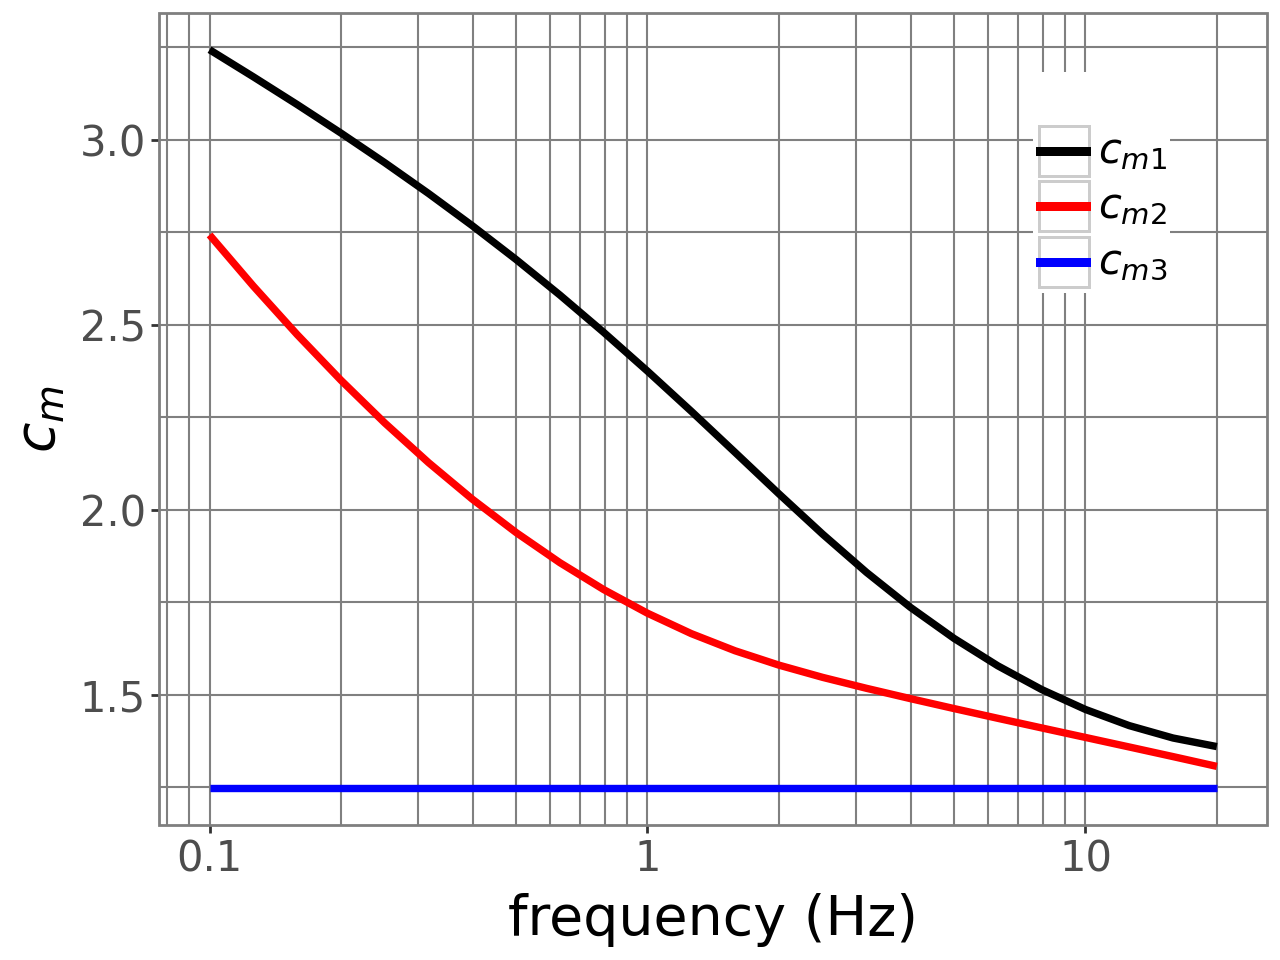

In [ ]:
def plot_cm(svi_params):
    df = pd.DataFrame({'frequency': svi_params['frequency'],
                      'c_m1': svi_params['c_m1'],
                      'c_m2': svi_params['c_m2'],
                      'c_m3': np.full(len(svi_params['frequency']), svi_params['c_m3'])})
    df = pd.melt(df, id_vars = 'frequency')

    pl = (ggplot(df, aes(x = 'frequency', y = 'value', color = 'variable')) +
          geom_line(size = 1.5) +
          scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
          scale_color_manual(values=['black', 'red', 'blue'],
                             labels = [r'$c_{m1}$', r'$c_{m2}$', r'$c_{m3}$']) +
          labs(y = '$c_{m}$', x = 'frequency (Hz)', color = '') +
          custom_theme +
          theme(legend_position = 'inside',
                legend_position_inside = (0.9,0.9)))
    return pl

pl = plot_cm(svi_params)
ggsave(pl, os.path.join(dir_plot, 'c_m.pdf'),
                        width = fig_width, height = fig_ratio * fig_width)
pl.show()

## Standard Deviations

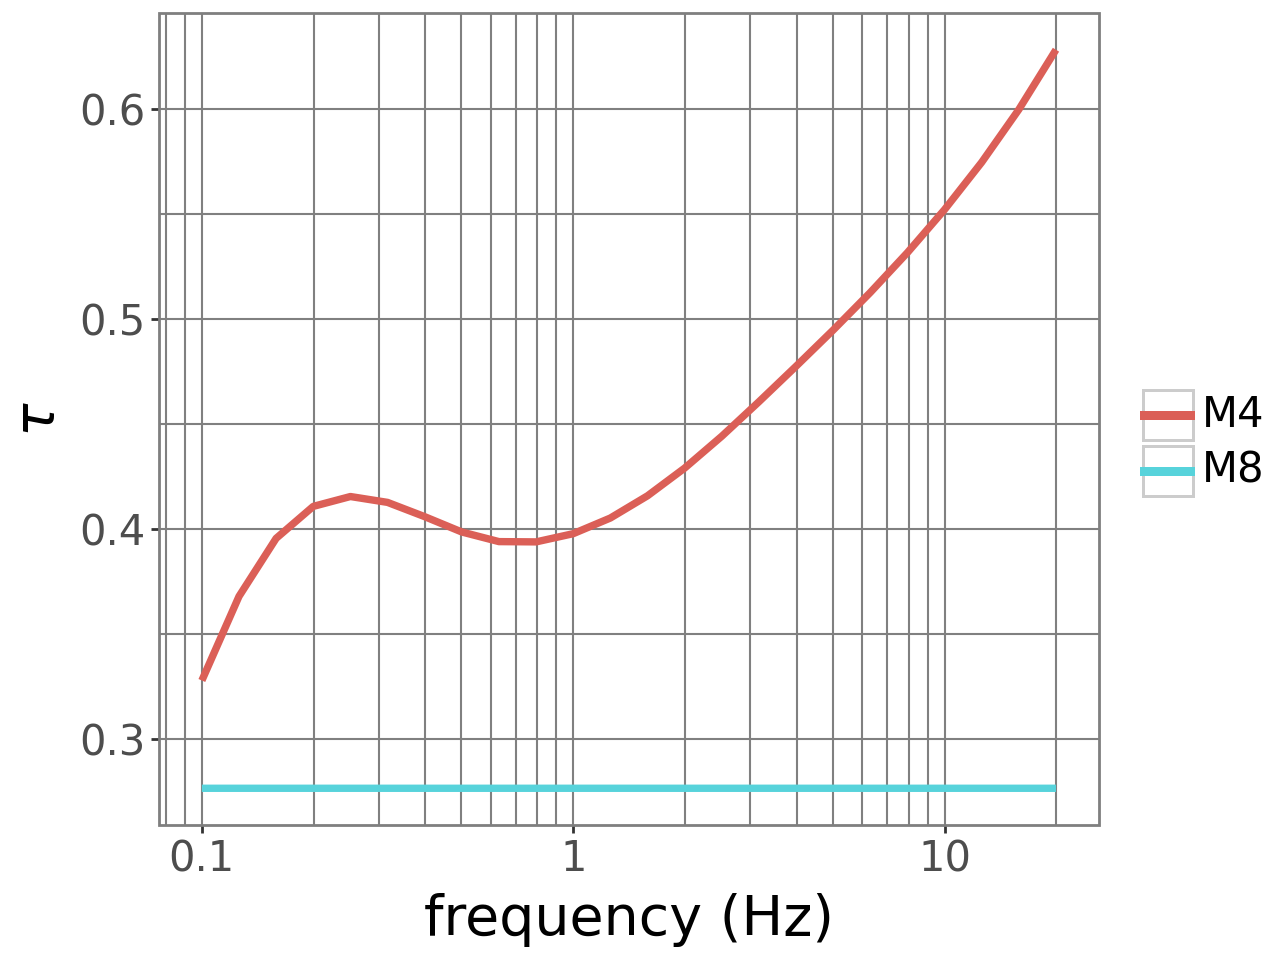

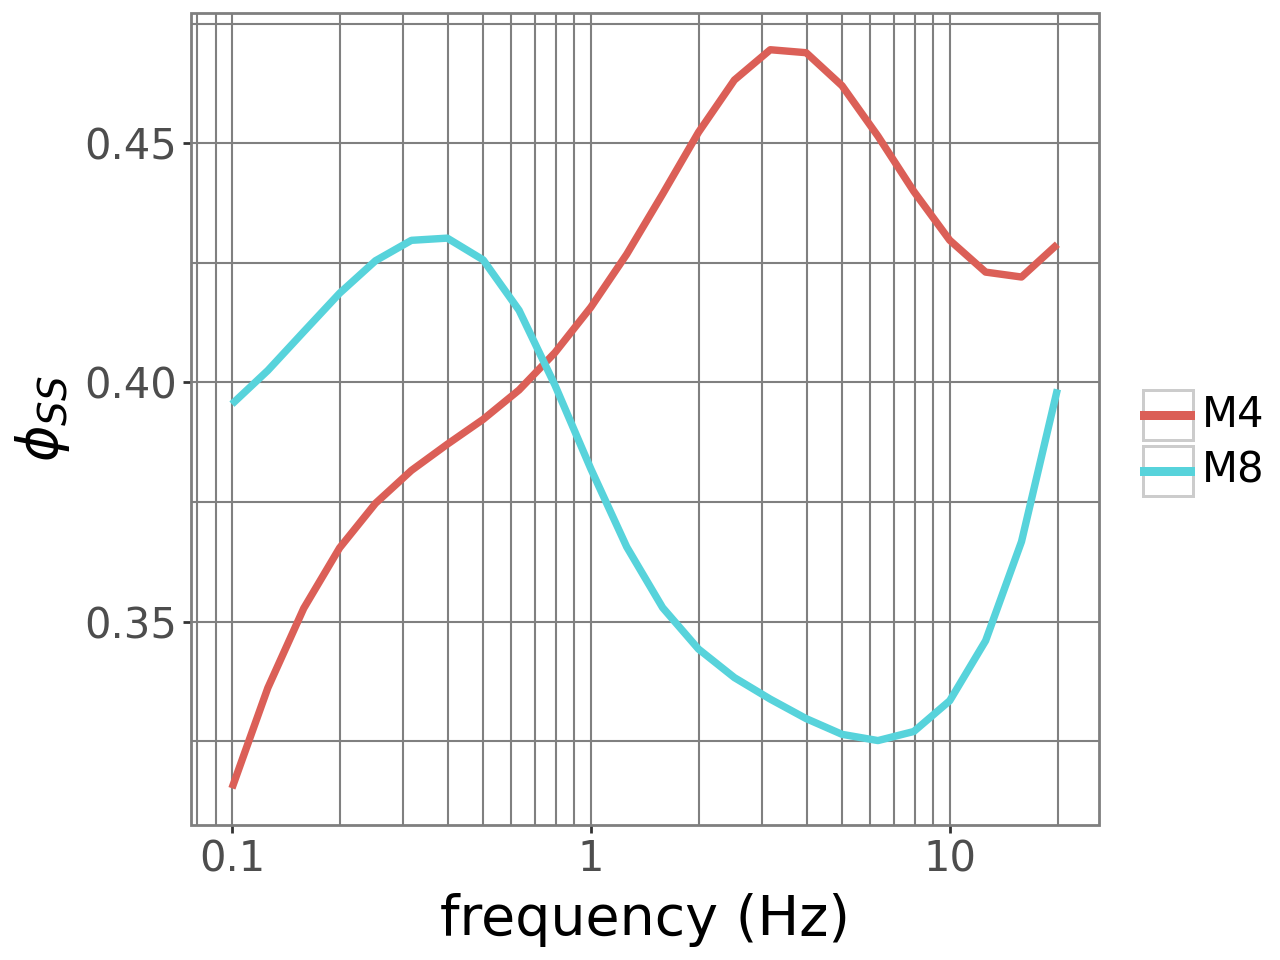

In [ ]:
def plot_sigma(par, deterministics):
    df = pd.DataFrame({'frequency': deterministics['frequency'],
                      'M4': jnp.exp(deterministics[f'{par}_0']),
                      'M8': jnp.exp(deterministics[f'{par}_1'])})
    df = pd.melt(df, id_vars = 'frequency')

    if par == 'tau':
        ylab = r'$\tau$'
    elif par == 'phi_ss':
        ylab = r'$\phi_{SS}$'
    else:
        raise ValueError('Unknown parameter')

    pl = (ggplot(df, aes(x = 'frequency', y = 'value', color = 'variable')) +
          geom_line(size = 1.5) +
          labs(y = ylab, x = 'frequency (Hz)', color = '') +
          scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
          custom_theme)
    pl.show()

plot_sigma('tau', svi_params)
plot_sigma('phi_ss', svi_params)

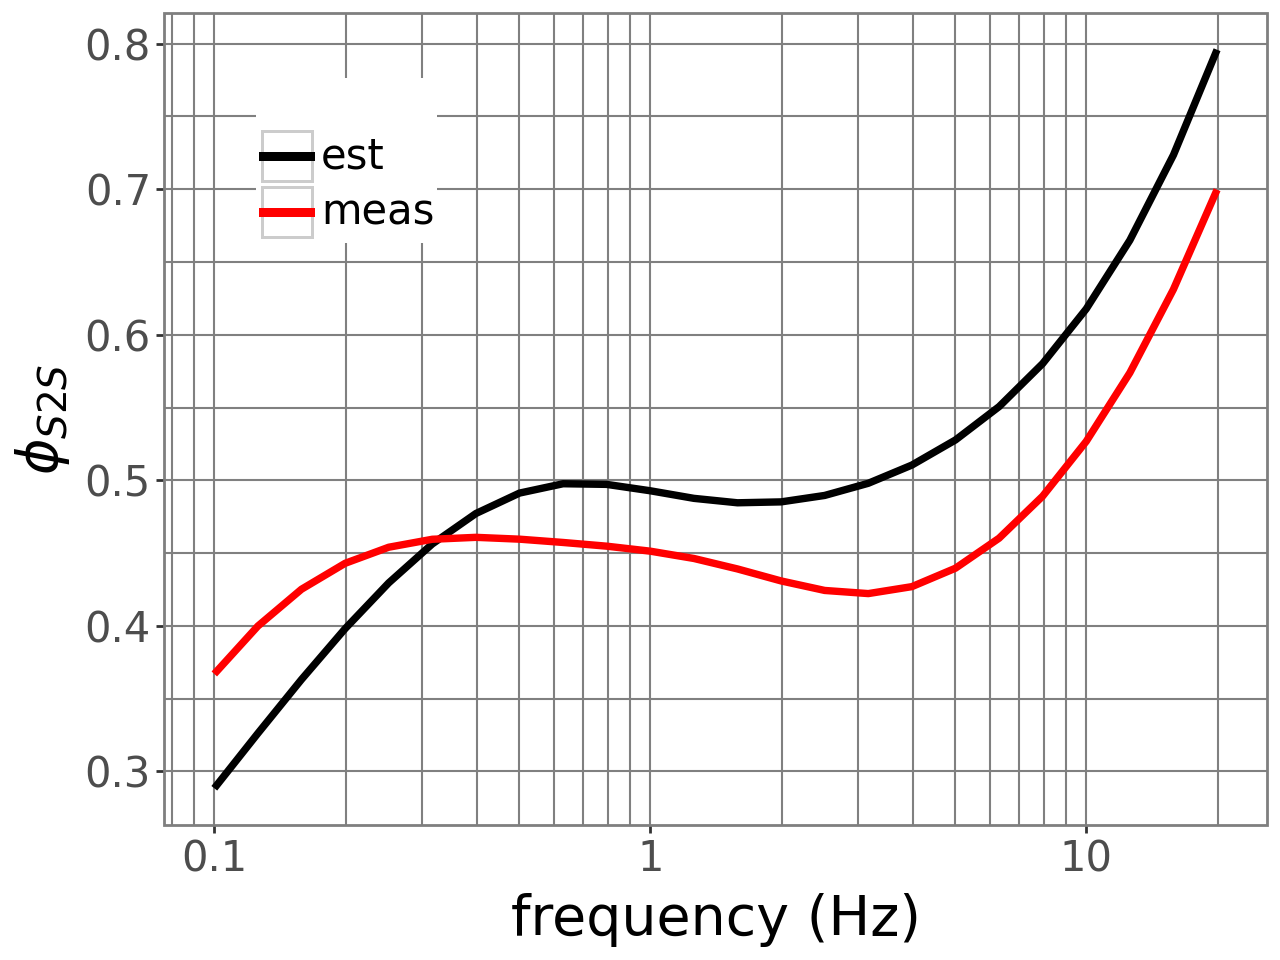

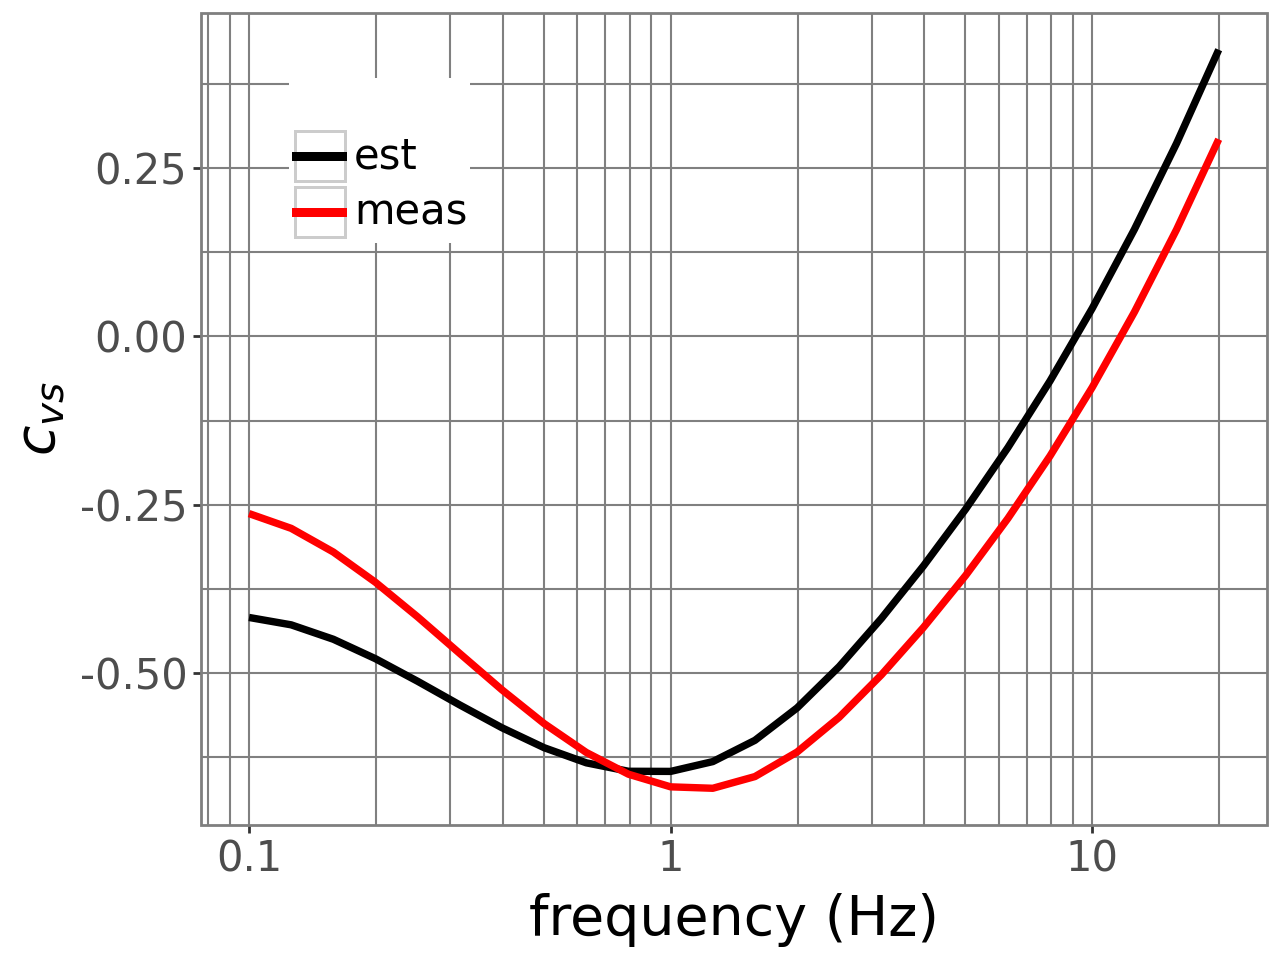

In [ ]:
def plot_sitepars(par, deterministics):
    df = pd.DataFrame({'frequency': deterministics['frequency'],
                      'meas': deterministics[f'{par}_meas'],
                      'est': deterministics[f'{par}_est']})
    df = pd.melt(df, id_vars = 'frequency')

    if par == 'phi_s2s':
        ylab = r'$\phi_{S2S}$'
    elif par == 'c_vs':
        ylab = r'$c_{vs}$'
    else:
        raise ValueError('Unknown parameter')

    pl = (ggplot(df, aes(x = 'frequency', y = 'value', color = 'variable')) +
          geom_line(size = 1.5) +
          scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
          labs(y = ylab, x = 'frequency (Hz)', color = '') +
          scale_color_manual(values = ['black', 'red']) +
          custom_theme +
          theme(legend_position='inside',
                legend_position_inside = (0.1,0.9)))
    return pl

pl = plot_sitepars('phi_s2s', svi_params)
pl.show()
plot_sitepars('c_vs', svi_params)

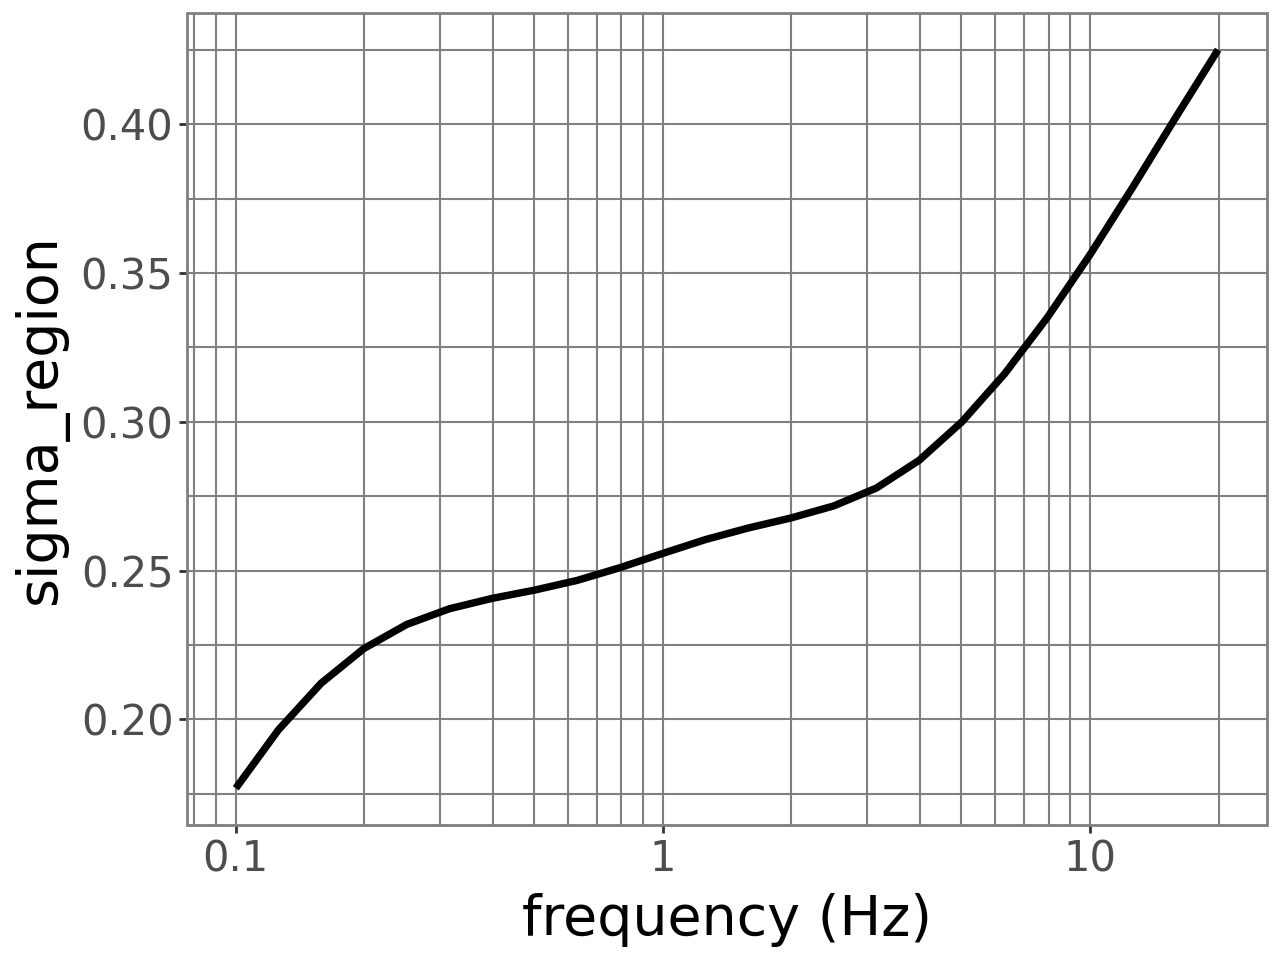

In [ ]:
pl = plot_parameter_against_frequency('sigma_region', svi_params)
pl.show()

## Random Effects

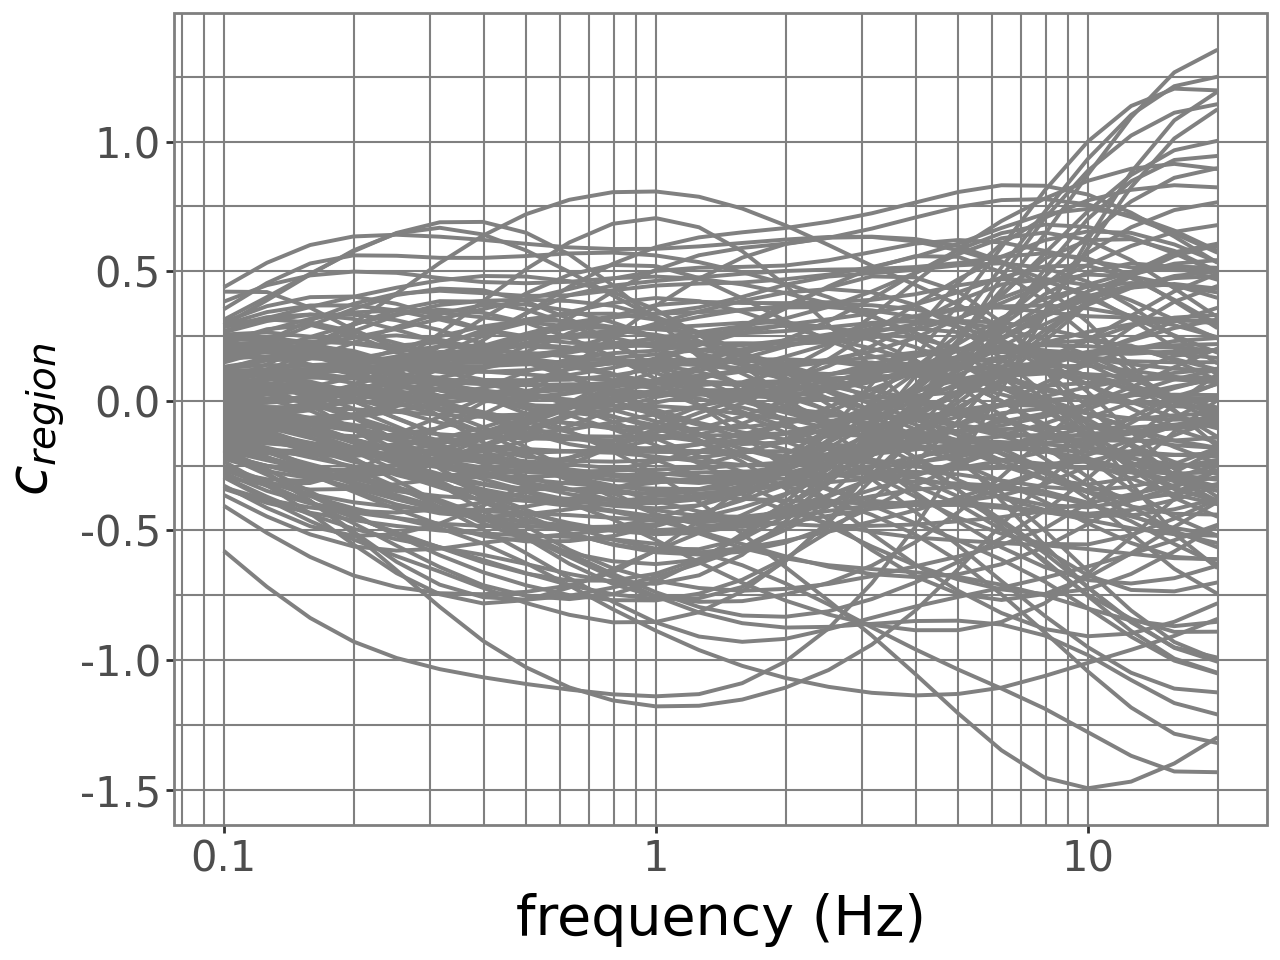

In [ ]:
def plot_region(svi_params):
    df = pd.DataFrame(svi_params['c_region'].T)
    df['frequency'] = svi_params['frequency']
    df = pd.melt(df, id_vars = 'frequency')

    pl = (ggplot(df, aes(x = 'frequency', y = 'value', group = 'variable')) +
      geom_line(size = 0.8, color = 'gray') +
      scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
      labs(y = r'$c_{region}$', x = 'frequency (Hz)') +
      custom_theme)
    return pl

pl = plot_region(svi_params)
pl.show()

In [ ]:
def plot_random_effect(svi_params, data, re_name, xvar, freq_id=[7,10,17,20],
                       log_x = False, ncol=None):
    freqs = svi_params['frequency']
    freq_names = np.array([f'f = {f:.3f}Hz' for f in freqs])

    if re_name == 'deltaB':
        ylab = r'$\delta B$'
    elif re_name == 'deltaB_attn':
        ylab = r'$\delta B_{attn}$'
    elif re_name == 'deltaS':
        ylab = r'$\delta S$'
    else:
        raise ValueError('Unknown random effect')

    if xvar == 'rrup':
        xlab = r'$R_{RUP} (km)$'
    elif xvar == 'magnitude':
        xlab = r'$\mathbf{M}$'
    elif xvar == 'ztor':
        xlab = r'$Z_{TOR} (km)$'
    elif xvar == 'vs30':
        xlab = r'$V_{S30} (m/s)$'
    elif xvar == 'z1p0_preferred':
        xlab = r'$Z_{1.0} (m)$'
    elif xvar == 'z2p5_preferred':
        xlab = r'$Z_{2.5} (m)$'
    else:
        raise ValueError('Unknown variable')

    df_val = pd.DataFrame(svi_params[re_name], columns=freq_names)
    df_val['x'] = data[xvar]
    df_val = pd.melt(df_val, id_vars='x', value_vars=freq_names[freq_id], value_name='value')

    df_scale = pd.DataFrame(svi_params[f'scale_{re_name}'], columns=freq_names)
    df_scale['x'] = data[xvar]
    df_scale = pd.melt(df_scale, id_vars='x', value_vars=freq_names[freq_id], value_name='scale')

    df = df_val.copy()
    df['scale'] = df_scale['scale']
    df['ymin'] = df['value'] - df['scale']
    df['ymax'] = df['value'] + df['scale']
    df['variable'] = pd.Categorical(df['variable'], categories=freq_names[freq_id])

    n = len(freq_id)
    if ncol is None:
        ncol = np.ceil(np.sqrt(n))
    nrow = np.ceil(n / ncol)

    pl = (ggplot(df, aes(x='x', y='value')) +
          geom_pointrange(aes(ymin='ymin', ymax='ymax'), size=2, fatten=2, raster = True) +
          facet_wrap('~variable', ncol=ncol, scales = 'free') +
          geom_smooth(method='lowess', color='red') +
          labs(x=xlab, y=ylab) +
          custom_theme)
    if log_x:
        pl = pl + scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks)
    return pl

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 16 x 12.8 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/deltaB_mag.pdf
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confide

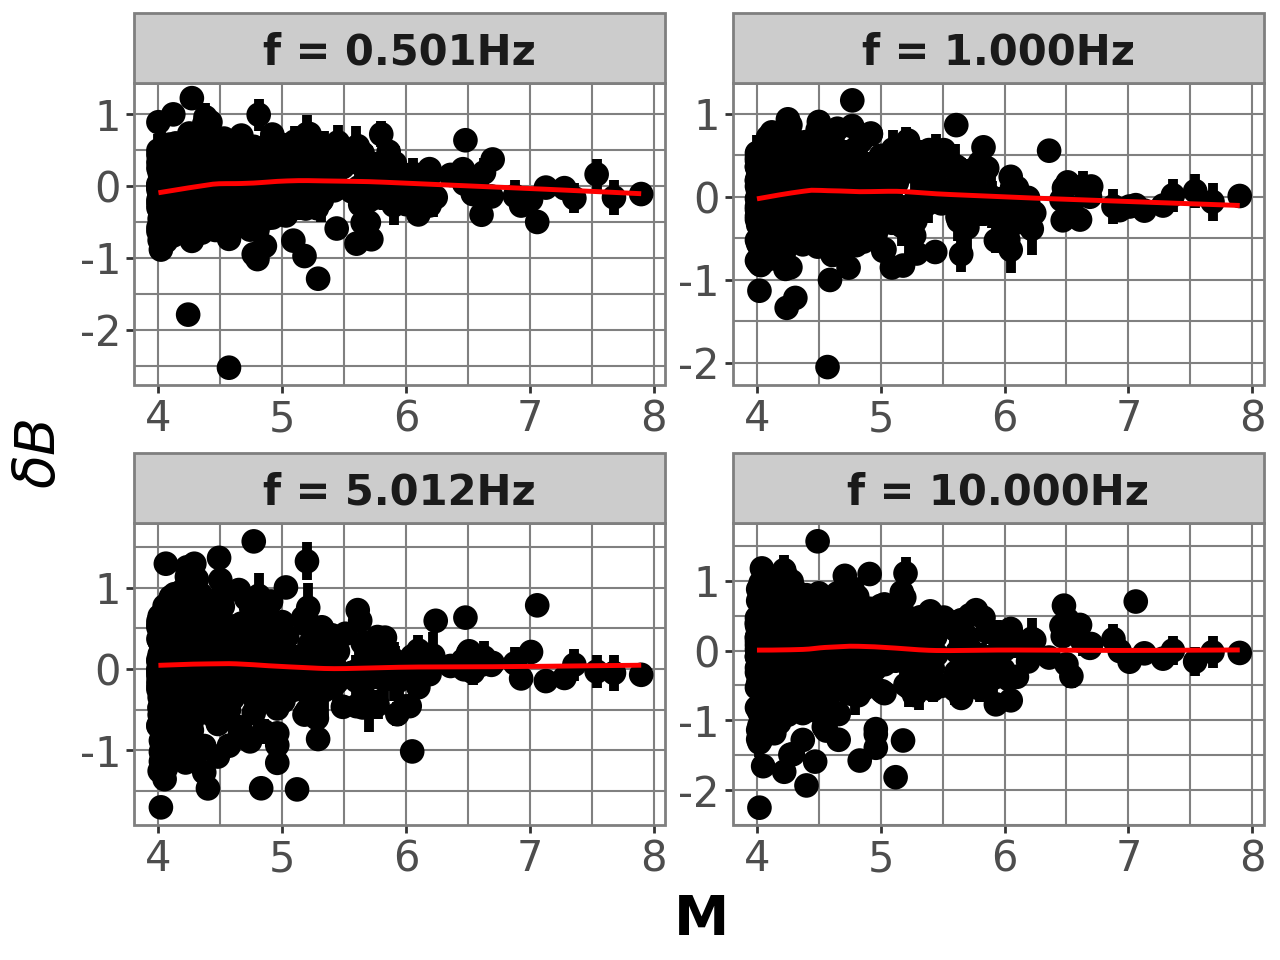

In [ ]:
pl = plot_random_effect(svi_params, data_eq, 'deltaB', 'magnitude')
# pl.save(os.path.join(dir_plot, 'deltaB_mag.pdf'))
ggsave(pl, os.path.join(dir_plot, 'deltaB_mag.pdf'),
                        width = 2 * fig_width, height = 2 * fig_ratio * fig_width, dpi = 600)
pl.show()

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 16 x 12.8 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/deltaB_ztor.pdf
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confid

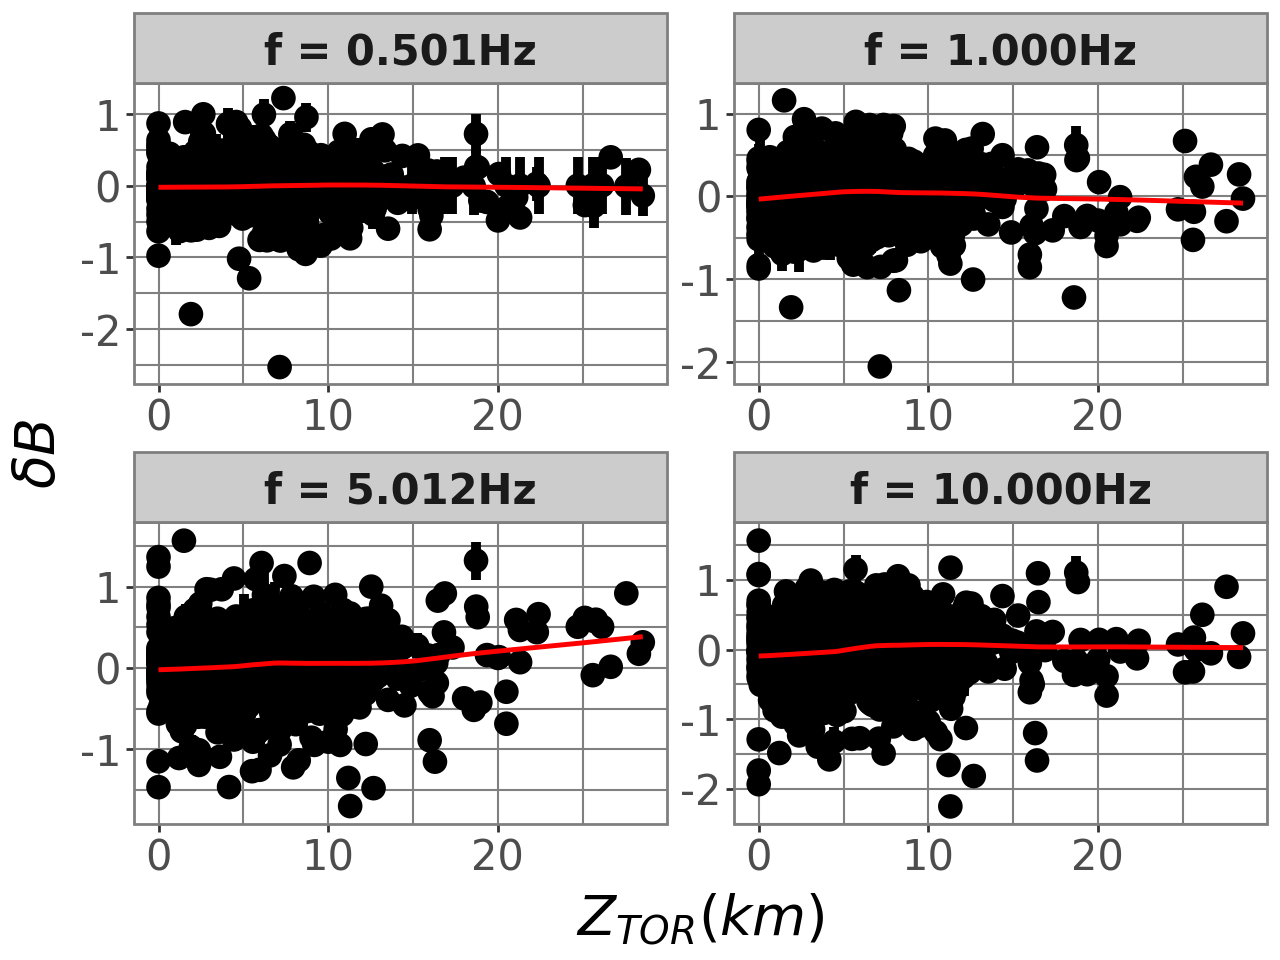

In [ ]:
pl = plot_random_effect(svi_params, data_eq, 'deltaB', 'ztor')
# pl.save(os.path.join(dir_plot, 'deltaB_ztor.pdf'))
ggsave(pl, os.path.join(dir_plot, 'deltaB_ztor.pdf'),
                        width = 2 * fig_width, height = 2 * fig_ratio * fig_width, dpi = 600)
pl.show()

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 16 x 12.8 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/deltaBattn_mag.pdf
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Con

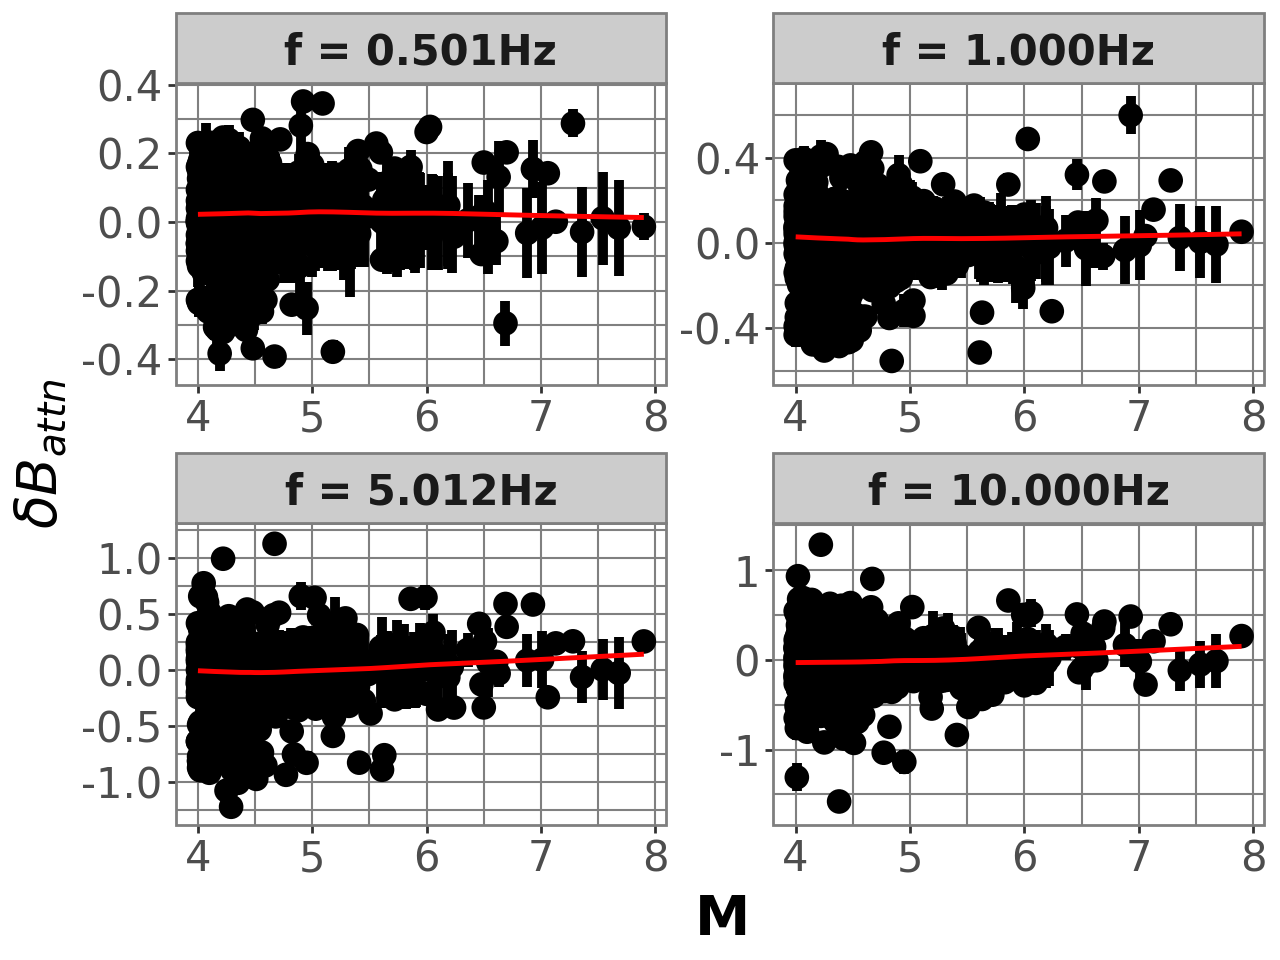

In [ ]:
pl = plot_random_effect(svi_params, data_eq, 'deltaB_attn', 'magnitude')
# pl.save(os.path.join(dir_plot, 'deltaBattn_mag.pdf'))
ggsave(pl, os.path.join(dir_plot, 'deltaBattn_mag.pdf'),
                        width = 2 * fig_width, height = 2 * fig_ratio * fig_width, dpi = 600)
pl.show()

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 16 x 12.8 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/deltaBattn_ztor.pdf
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Co

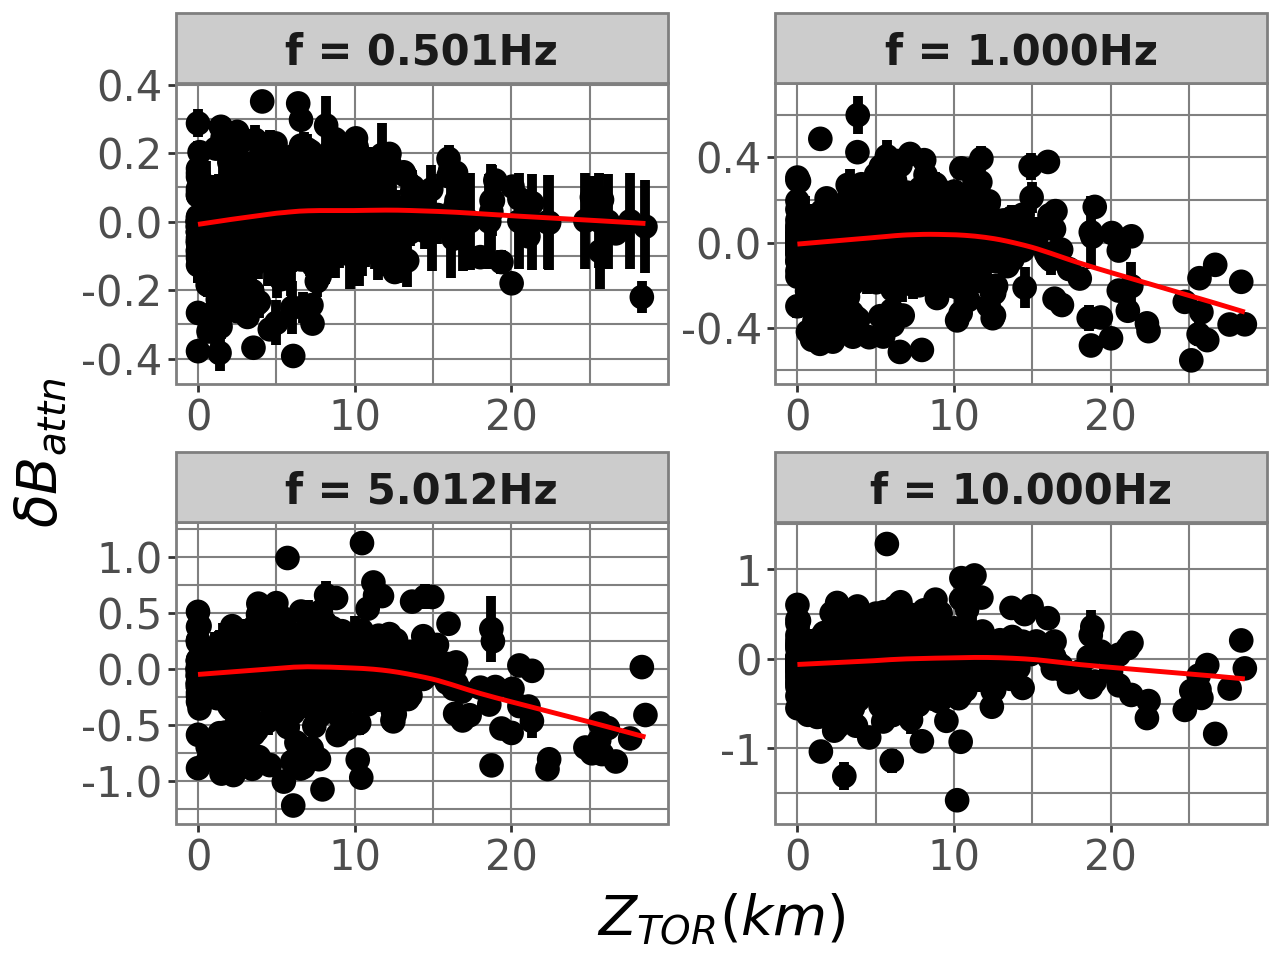

In [ ]:
pl = plot_random_effect(svi_params, data_eq, 'deltaB_attn', 'ztor')
# pl.save(os.path.join(dir_plot, 'deltaBattn_ztor.pdf'))
ggsave(pl, os.path.join(dir_plot, 'deltaBattn_ztor.pdf'),
                        width = 2 * fig_width, height = 2 * fig_ratio * fig_width, dpi = 600)
pl.show()

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 16 x 12.8 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/deltaS_vs30.pdf
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confid

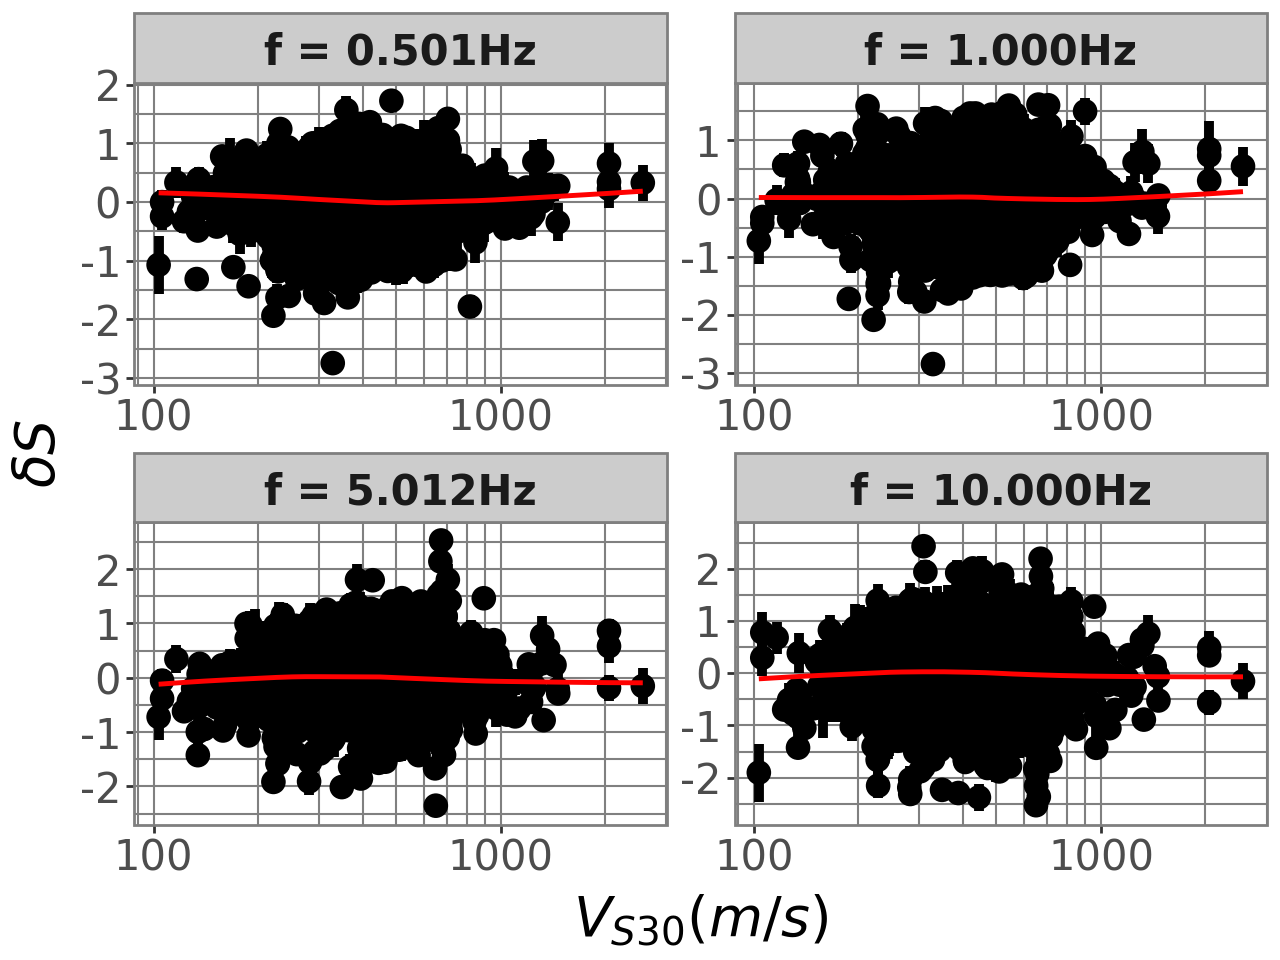

In [ ]:
pl = plot_random_effect(svi_params, data_stat, 'deltaS', 'vs30', log_x = True)
# pl.save(os.path.join(dir_plot, 'deltaS_vs30.pdf'))
ggsave(pl, os.path.join(dir_plot, 'deltaS_vs30.pdf'),
                        width = 2 * fig_width, height = 2 * fig_ratio * fig_width, dpi = 600)
pl.show()

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 16 x 12.8 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/deltaS_z10.pdf
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/l

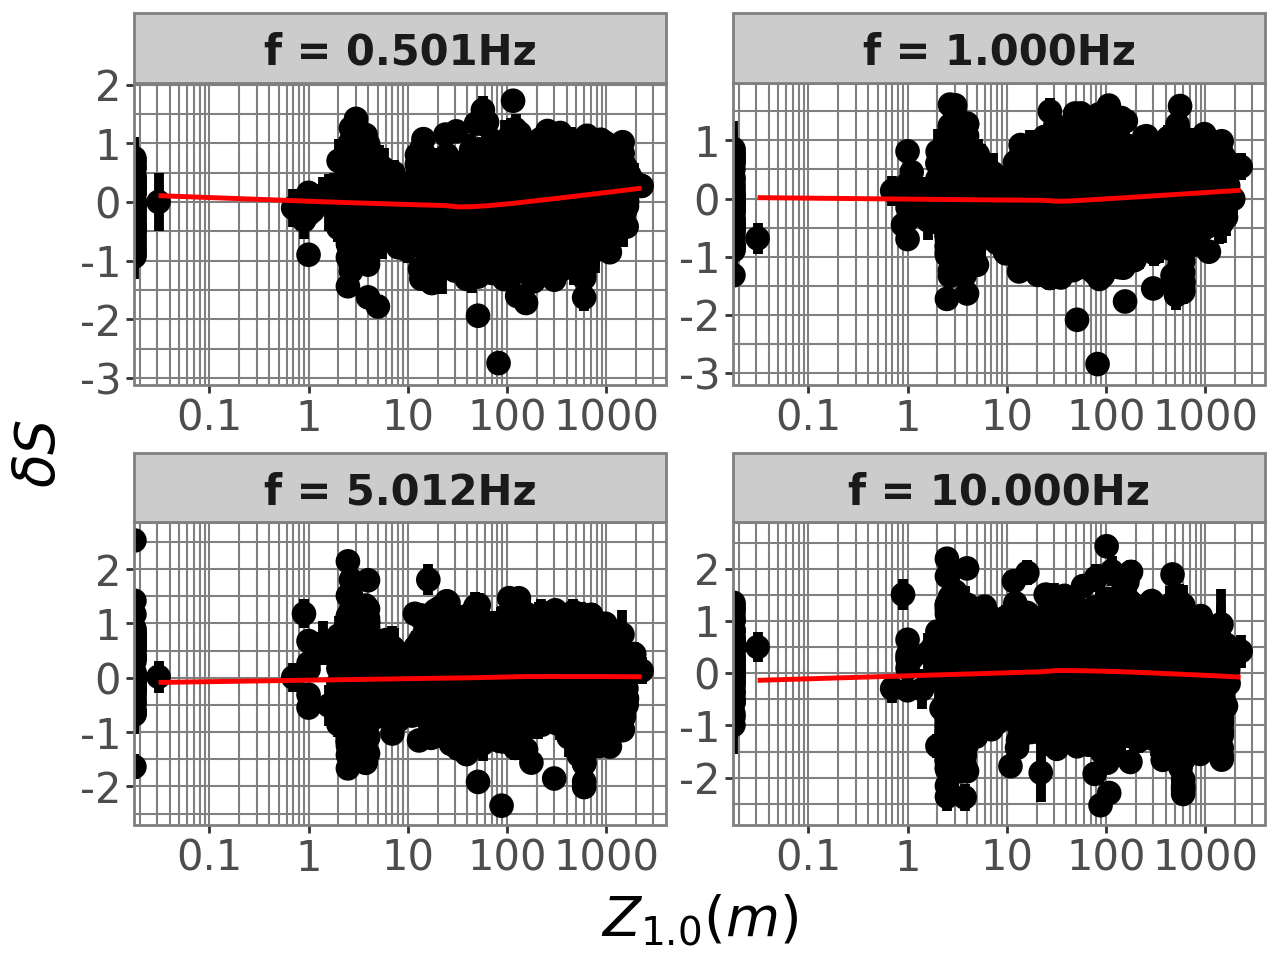

In [ ]:
pl = plot_random_effect(svi_params, data_stat, 'deltaS', 'z1p0_preferred', log_x = True)
# pl.save(os.path.join(dir_plot, 'deltaS_z10.pdf'))
ggsave(pl, os.path.join(dir_plot, 'deltaS_z10.pdf'),
                        width = 2 * fig_width, height = 2 * fig_ratio * fig_width, dpi = 600)
pl.show()

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 16 x 12.8 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/deltaS_z25.pdf
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/l

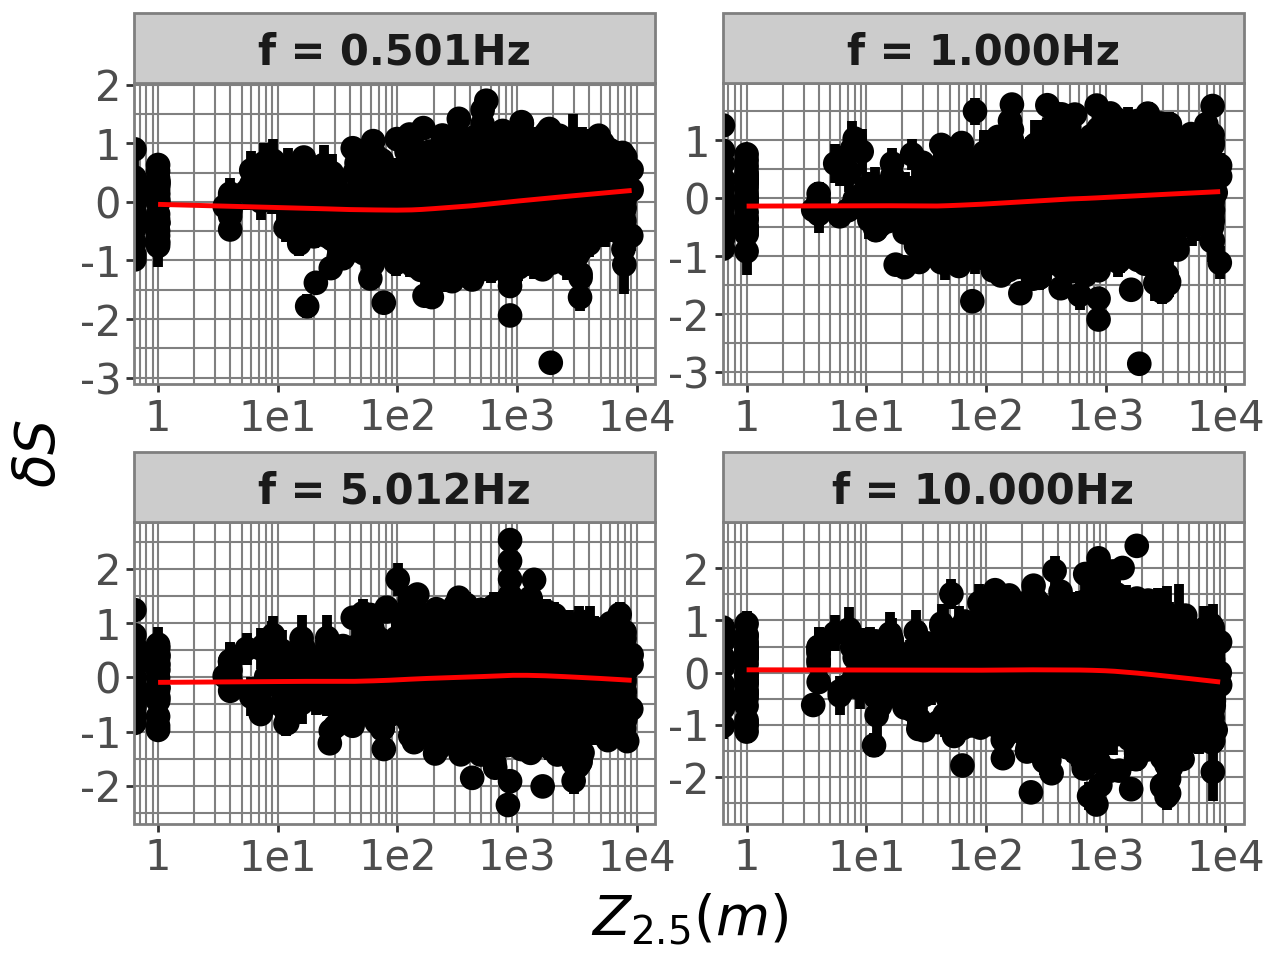

In [ ]:
pl = plot_random_effect(svi_params, data_stat, 'deltaS', 'z2p5_preferred', log_x = True)
# pl.save(os.path.join(dir_plot, 'deltaS_z25.pdf'))
ggsave(pl, os.path.join(dir_plot, 'deltaS_z25.pdf'),
                        width = 2 * fig_width, height = 2 * fig_ratio * fig_width, dpi = 600)
pl.show()

In [ ]:
def plot_random_effect_qq(svi_params, re_name, freq_id=[7,10,17,20], ncol=None):
    freqs = svi_params['frequency']
    freq_names = np.array([f'f = {f:.3f}Hz' for f in freqs])

    if re_name == 'deltaB':
        ylab = r'$\delta B$'
    elif re_name == 'deltaB_attn':
        ylab = r'$\delta B_{attn}$'
    elif re_name == 'deltaS':
        ylab = r'$\delta S$'
    else:
        raise ValueError('Unknown random effect')

    df_val = pd.DataFrame(svi_params[re_name], columns=freq_names)
    df_val = pd.melt(df_val, value_vars=freq_names[freq_id], value_name='value')

    df = df_val.copy()
    df['variable'] = pd.Categorical(df['variable'], categories=freq_names[freq_id])

    n = len(freq_id)
    if ncol is None:
        ncol = np.ceil(np.sqrt(n))
    nrow = np.ceil(n / ncol)

    pl = (ggplot(df, aes(sample= 'value')) +
          stat_qq() + stat_qq_line(color = 'red') +
          facet_wrap('~variable', ncol=ncol, scales = 'free') +
          labs(title=ylab) +
          custom_theme)
    return pl

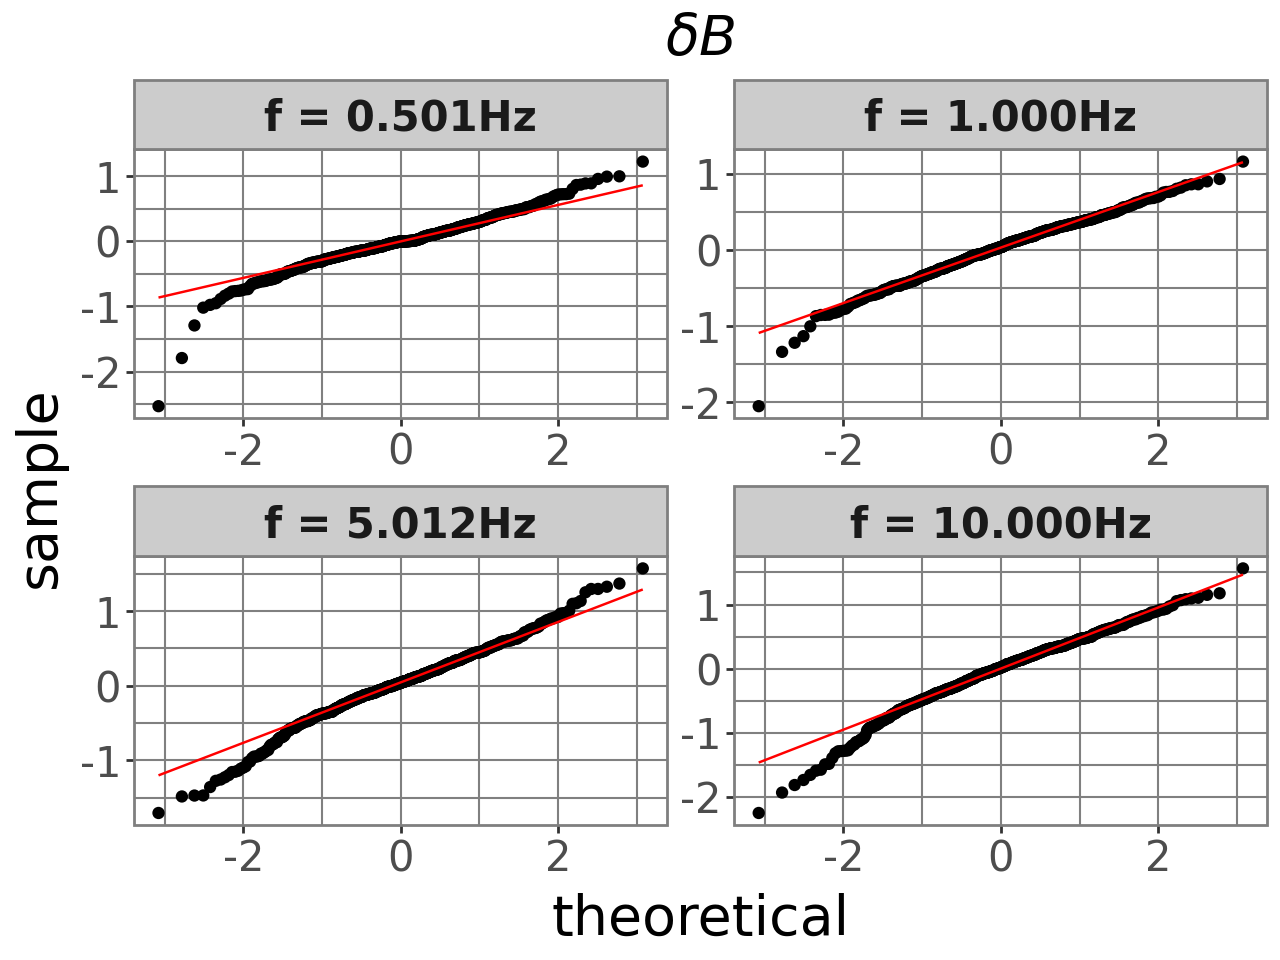

In [ ]:
plot_random_effect_qq(svi_params, 'deltaB')

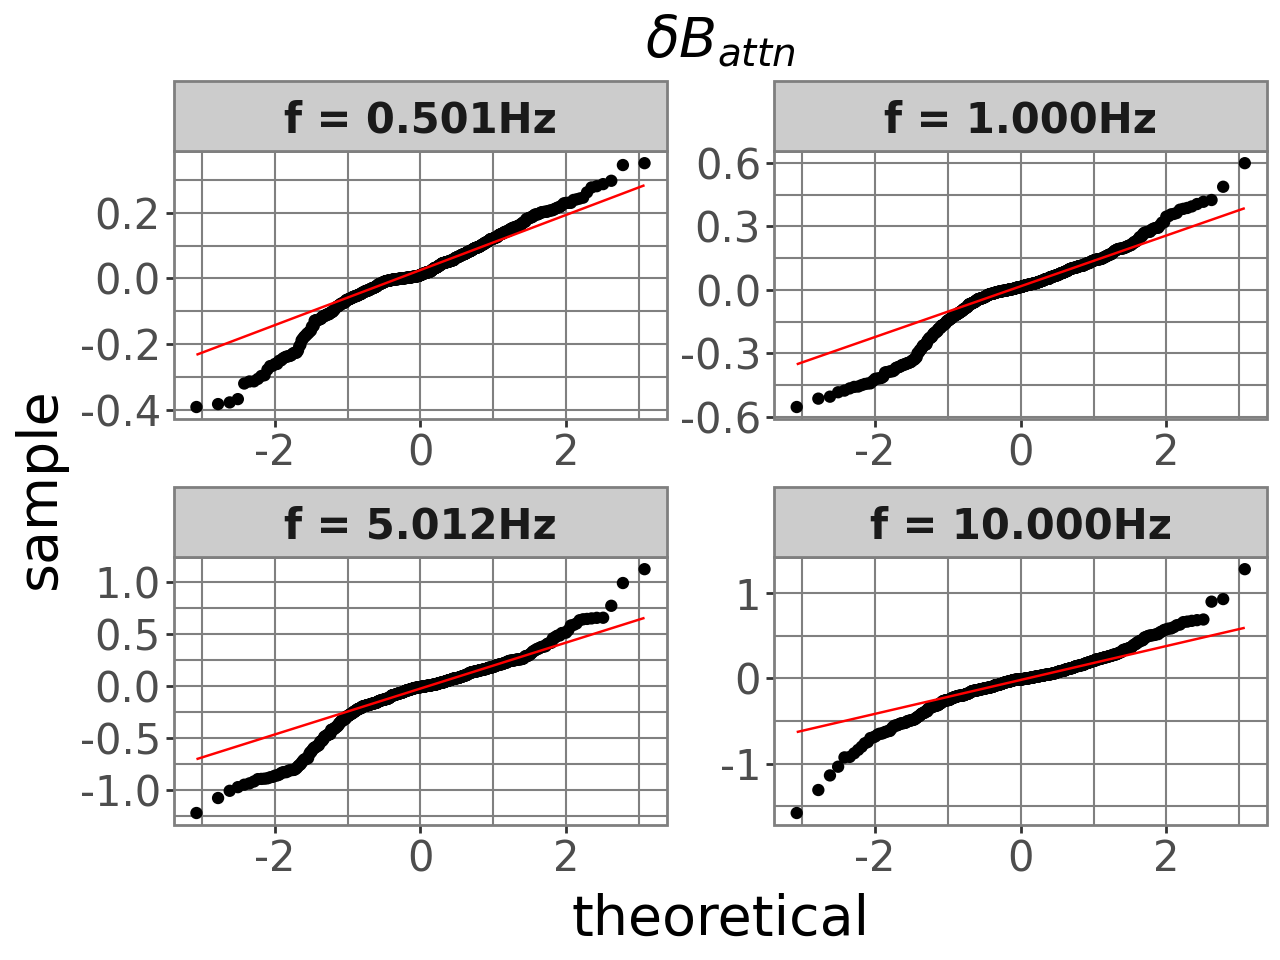

In [ ]:
plot_random_effect_qq(svi_params, 'deltaB_attn')

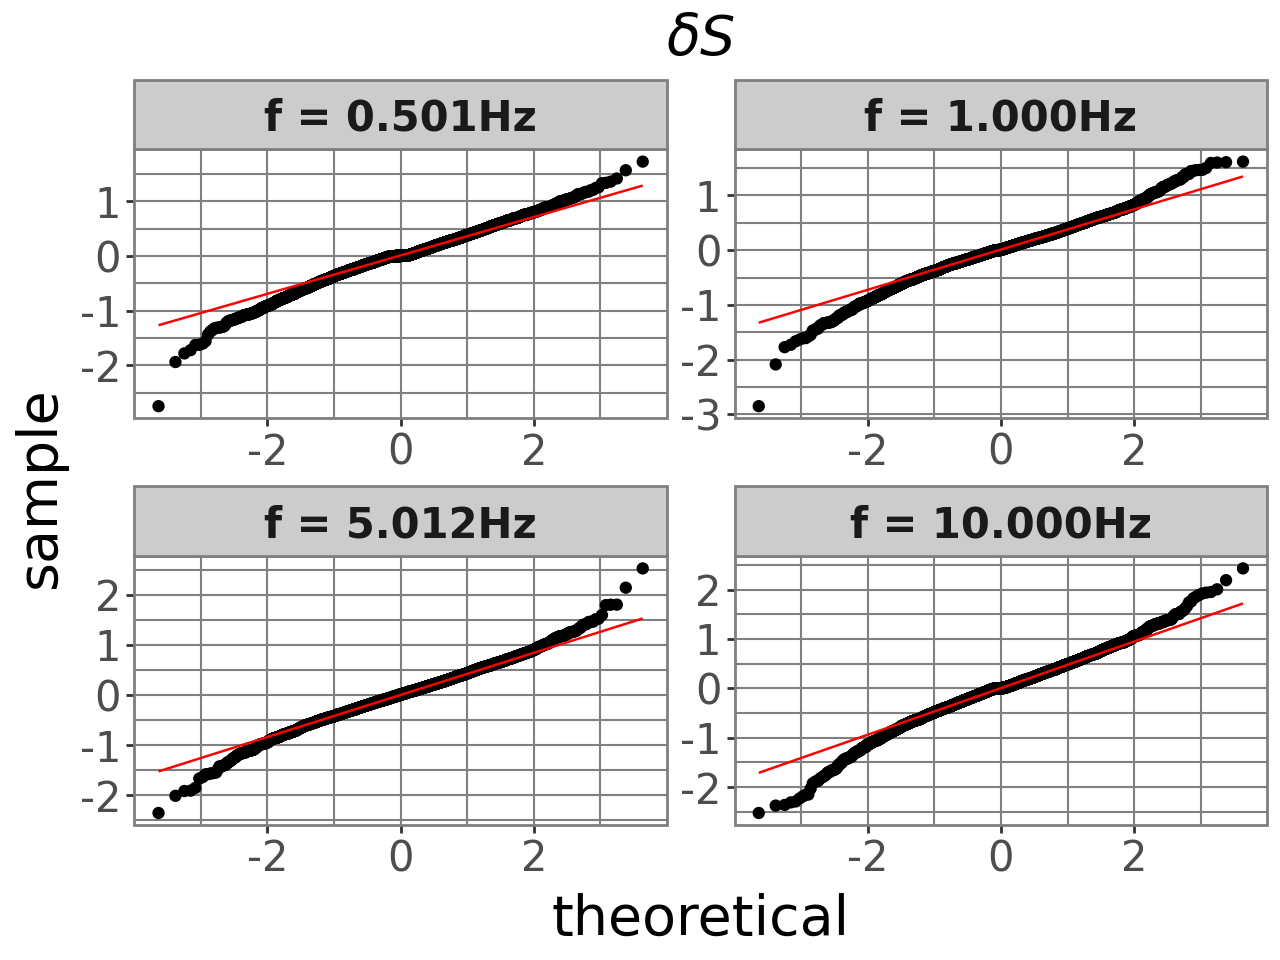

In [ ]:
plot_random_effect_qq(svi_params, 'deltaS')

## Single-Site Residuals

In [ ]:
from ngaw3_kuehnetal27.scenario_prediction import compute_deltaWS

In [ ]:
deltaWS = compute_deltaWS(data_dict, svi_params)
deltaWS.shape

(57913, 24)

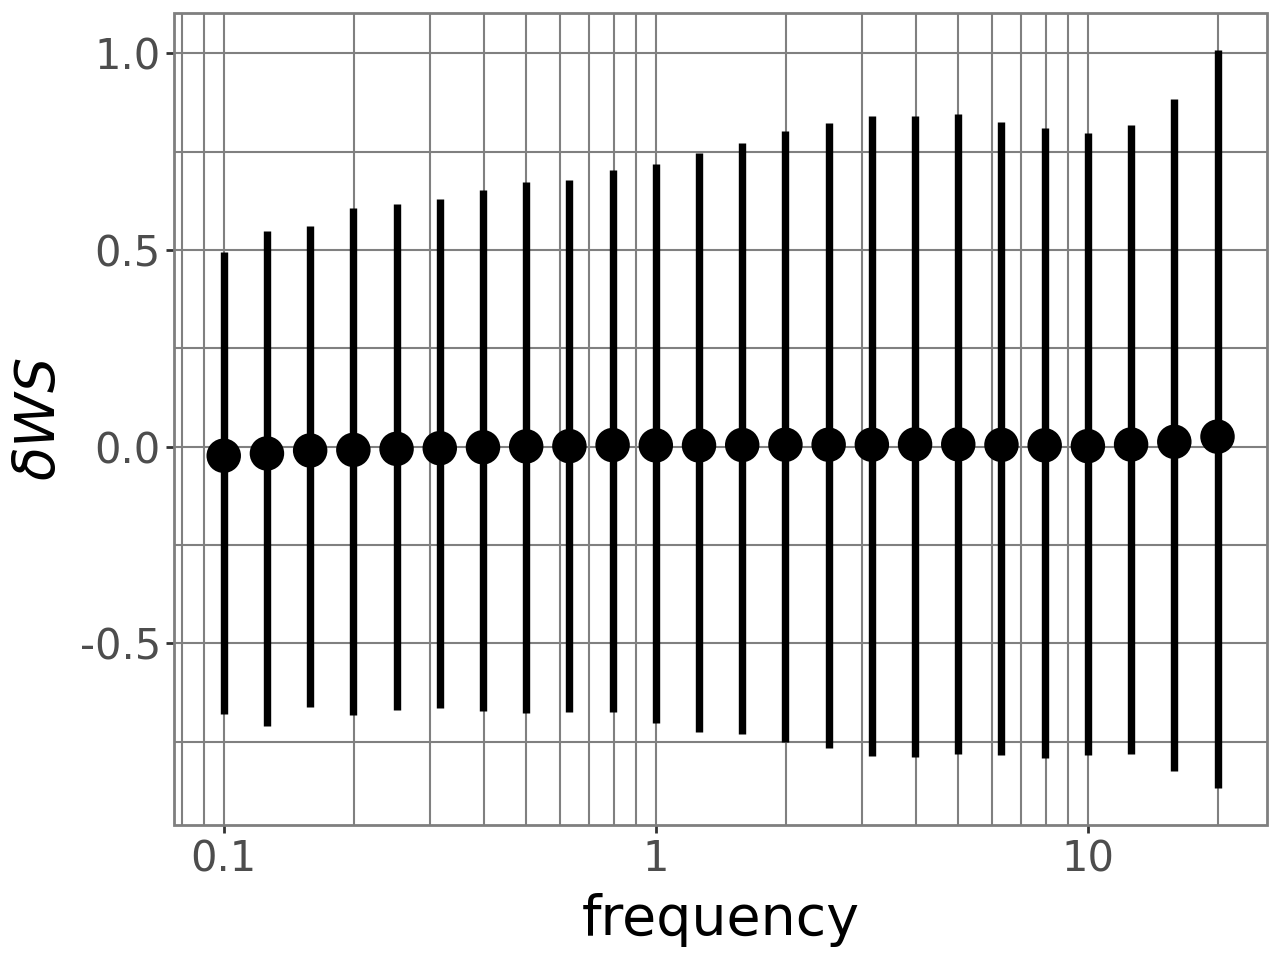

In [ ]:
df = pd.DataFrame({'frequency': svi_params['frequency'],
                   'mean': np.nanmean(deltaWS, axis = 0),
                   'q05': np.nanquantile(deltaWS, 0.05, axis = 0),
                   'q95':np.nanquantile(deltaWS, 0.95, axis = 0)})

pl = (ggplot(df, aes(x = 'frequency', y = 'mean', ymin = 'q05', ymax = 'q95')) +
      geom_pointrange(size = 1.5) +
      scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
      labs(y = r'$\delta WS$') +
      custom_theme)
pl.show()

In [ ]:
def plot_deltaWS(deltaWS, data, xvar, freqs, freq_id=[7,10,17,20],
                       log_x = False, ncol=None):
    freq_names = np.array([f'f = {f:.3f}Hz' for f in freqs])

    df = pd.DataFrame(deltaWS, columns=freq_names)
    df['x'] = data[xvar]
    df = pd.melt(df, id_vars='x', value_vars=freq_names[freq_id], value_name='value')
    df['variable'] = pd.Categorical(df['variable'], categories=freq_names[freq_id])

    n = len(freq_id)
    if ncol is None:
        ncol = np.ceil(np.sqrt(n))
    nrow = np.ceil(n / ncol)

    pl = (ggplot(df, aes(x='x', y='value')) +
          geom_point(size=2, raster = True) +
          facet_wrap('~variable', ncol=ncol, scales = 'free') +
          geom_smooth(method='lowess', color='red') +
          labs(x=xvar, y=r'$\delta aWS$') +
          custom_theme)
    if log_x:
        pl = pl + scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks)
    return pl

In [ ]:
pl = plot_deltaWS(deltaWS, data_used, 'rrup', frequencies_used, log_x = True)
ggsave(pl, os.path.join(dir_plot, 'deltaWS_rrup.pdf'),
                        width = 2 * fig_width, height = 2 * fig_ratio * fig_width, dpi = 600)

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 16 x 12.8 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/deltaWS_rrup.pdf
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Re

## Prediction

In [ ]:
from ngaw3_kuehnetal27.scenario_prediction import scenario_predict, DEFAULTS

In [ ]:
names_freqs = [f"f{f:.3f}" for f in frequencies]

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 16 x 12.8 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/spectrum.pdf


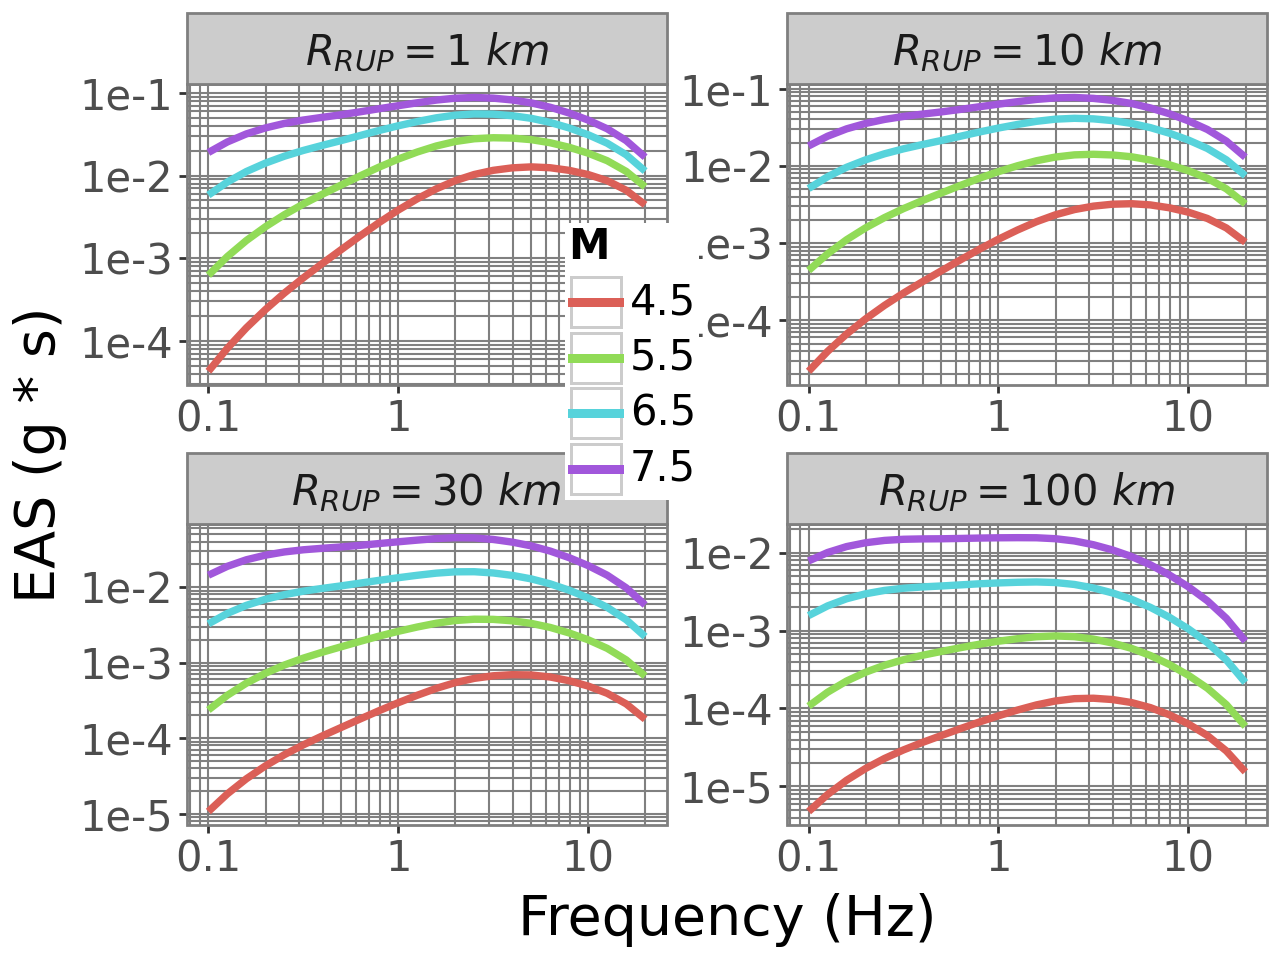

In [ ]:
def plot_spectrum():
    magnitudes = np.array([4.5, 5.5, 6.5, 7.5])
    rrup = np.array([1, 10, 30, 100])
    df_sc, ln_median = scenario_predict(
        svi_params, frequencies, nl_model_dict=nl_model_dict,
        M=magnitudes,
        R=rrup
    )
    df_sc['M'] = pd.Categorical(df_sc['M'])
    df_sc['R'] = pd.Categorical(df_sc['R'])

    df = pd.melt(df_sc, id_vars=['M', 'R'], value_vars=names_freqs)
    df['value'] = np.exp(df['value'])

    freq_map = {f"f{p:.3f}": float(p) for p in frequencies}
    df['frequency'] = df['variable'].map(freq_map).astype(float)

    # dict mapping the categorical *string* value to the LaTeX label
    rrup_labels = {str(r): rf'$R_{{RUP}} = {r}\ km$' for r in rrup}

    pl = (ggplot(df, aes(x='frequency', y='value', color='M')) +
          geom_line(size=1.5) +
          facet_wrap('~R', scales='free', labeller=labeller(R=lambda s: rf'$R_{{RUP}} = {s}\ km$')) +
          scale_x_log10(breaks=log_breaks, minor_breaks=log_minor_breaks) +
          scale_y_log10(breaks=log_breaks, minor_breaks=log_minor_breaks) +
          labs(x='Frequency (Hz)',
               y='EAS (g * s)',
               color=r'$\mathbf{M}$') +
          custom_theme +
          theme(legend_position='inside',
                legend_position_inside=(0.4,0.7)))
    return pl
pl = plot_spectrum()
ggsave(pl, os.path.join(dir_plot, 'spectrum.pdf'),
                        width = 2 * fig_width, height = 2 * fig_ratio * fig_width)
pl.show()

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 16 x 6.4 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/magscaling.pdf


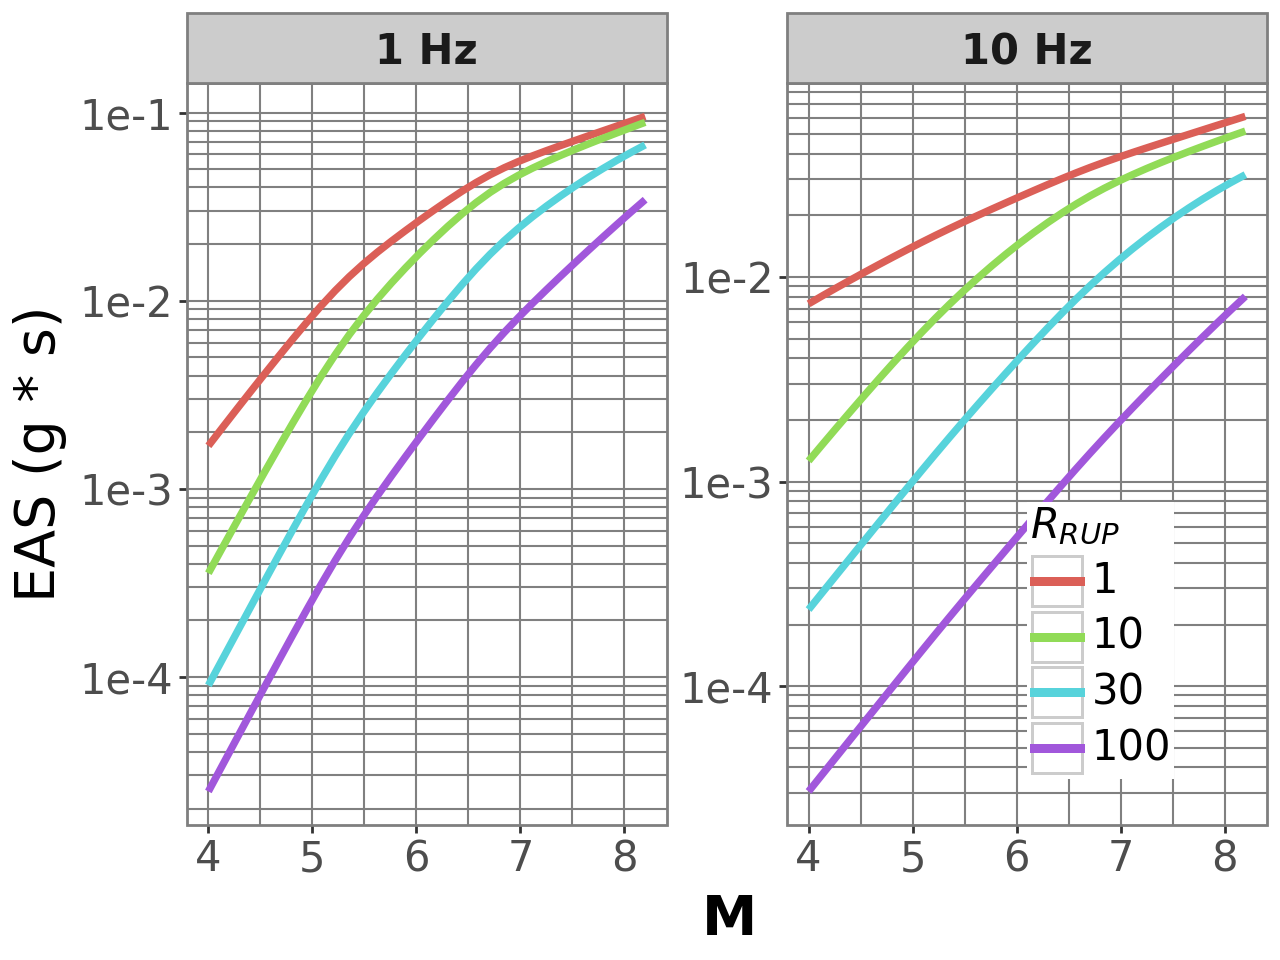

In [ ]:
def plot_magscaling():
    magnitudes = np.linspace(4, 8.2,32)
    rrup = np.array([1, 10, 30, 100])
    df_sc, ln_median = scenario_predict(
        svi_params, frequencies, nl_model_dict=nl_model_dict,
        M=magnitudes,
        R=rrup
    )
    df_sc['R'] = pd.Categorical(df_sc['R'])

    df = pd.melt(df_sc, id_vars=['M', 'R'], value_vars=names_freqs)
    df['value'] = np.exp(df['value'])

    freq_map = {f"f{p:.3f}": float(p) for p in frequencies}
    df['frequency'] = df['variable'].map(freq_map).astype(float)

    freqs_plot = ['f1.000', 'f10.000']
    df = pd.melt(df_sc, id_vars= ['M', 'R'], value_vars=freqs_plot)
    df['value'] = np.exp(df['value'])

    label = {'f1.000': '1 Hz', 'f10.000': '10 Hz'}
    df.replace({'variable': label}, inplace=True)

    pl = (ggplot(df, aes(x = 'M', y = 'value', color = 'R')) +
          geom_line(size=1.5) +
          facet_wrap('~variable', scales = 'free') +
          scale_y_log10(breaks=log_breaks, minor_breaks=log_minor_breaks) +
          labs(x=r'$\mathbf{M}$',
                y='EAS (g * s)',
                color=r'$R_{RUP}$') +
          custom_theme +
          theme(legend_position='inside',
                legend_position_inside=(0.9,0.1)))
    return pl

pl = plot_magscaling()
ggsave(pl, os.path.join(dir_plot, 'magscaling.pdf'),
                        width = 2 * fig_width, height = fig_ratio * fig_width)
pl.show()

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 16 x 6.4 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/distscaling.pdf


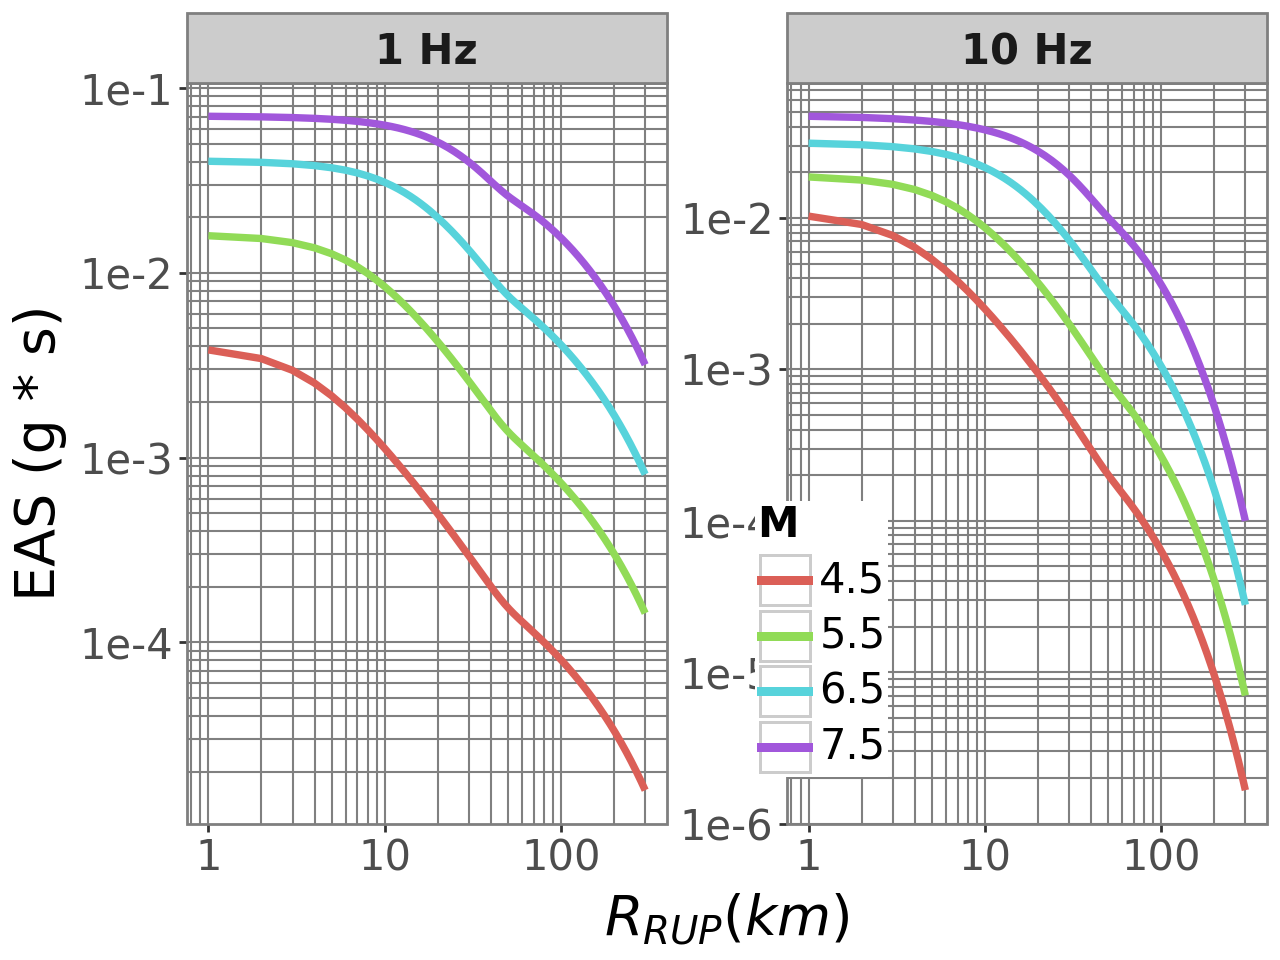

In [ ]:
def plot_distscaling():
    magnitudes = np.array([4.5, 5.5, 6.5, 7.5])
    rrup = np.linspace(1, 300, 301)
    df_sc, ln_median = scenario_predict(
        svi_params, frequencies, nl_model_dict=nl_model_dict,
        M=magnitudes,
        R=rrup
    )
    df_sc['M'] = pd.Categorical(df_sc['M'])

    df = pd.melt(df_sc, id_vars=['M', 'R'], value_vars=names_freqs)
    df['value'] = np.exp(df['value'])

    freq_map = {f"f{p:.3f}": float(p) for p in frequencies}
    df['frequency'] = df['variable'].map(freq_map).astype(float)

    freqs_plot = ['f1.000', 'f10.000']
    df = pd.melt(df_sc, id_vars= ['M', 'R'], value_vars=freqs_plot)
    df['value'] = np.exp(df['value'])

    label = {'f1.000': '1 Hz', 'f10.000': '10 Hz'}
    df.replace({'variable': label}, inplace=True)

    pl = (ggplot(df, aes(x = 'R', y = 'value', color = 'M')) +
          geom_line(size=1.5) +
          facet_wrap('~variable', scales = 'free') +
          scale_x_log10(breaks=log_breaks, minor_breaks=log_minor_breaks) +
          scale_y_log10(breaks=log_breaks, minor_breaks=log_minor_breaks) +
          labs(x=r'$R_{RUP} (km)$',
                y='EAS (g * s)',
                color=r'$\mathbf{M}$') +
          custom_theme +
          theme(legend_position='inside',
                legend_position_inside=(0.6,0.1)))
    return pl

pl = plot_distscaling()
ggsave(pl, os.path.join(dir_plot, 'distscaling.pdf'),
                        width = 2 * fig_width, height = fig_ratio * fig_width)
pl.show()